In [203]:
import pandas as pd
import time

In [204]:
start=time.perf_counter()

In [205]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [206]:
from FPLPredictor import FPLPredictor

In [207]:
#add this info to a settings dict?
stats_current_gameweek = 16
picks_current_gameweek = 16
current_season = 20252026

In [208]:
# Load df from sql
df = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147334 entries, 0 to 147333
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 483.3+ MB


In [209]:
df.columns.tolist()

['player_name_id',
 'element',
 'season',
 'value',
 'event',
 'minutes',
 'total_points',
 'team_elo',
 'opp_team_elo',
 'position',
 'goals_scored',
 'bonus',
 'bps',
 'clean_sheets',
 'goals_conceded',
 'was_home',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'team_name',
 'opp_team_name',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles',
 'saves',
 'player_season_minutes_total',
 'player_season_points_per90',
 'points_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'expected_goals_conceded_per90',
 'saves_per90',
 'bps_per90',
 'bonus_per90',
 'cbi_per90',
 'defensive_contribution_per90',
 'recoveries_per90',
 'tackles_per90',
 'elo_diff',
 'xgoal_involvements_x_defensive_cont_p90_at',
 'xgoal_involvements_x_defensive_cont_at',
 'xgoal_involvements_x_defensive_cont_p90_3',
 'xgoal_involvements_x_defensive_cont_3',
 'xgoal_involvements_x_defensive_cont_elo_p90_3',
 'xgoal_involvements_x_defensive_cont_p9

In [210]:
df[df['xgoals_p90sq_at']==0].pivot_table(index='season', values='xgoals_p90sq_at', aggfunc='count')

,xgoals_p90sq_at
season,
20182019.0,13992
20192020.0,14533
20202021.0,14557
20212022.0,16886
20222023.0,10789
20232024.0,3882
20242025.0,3924
20252026.0,2821


In [211]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
#    &(df['event']==9)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name
132061,Bukayo Saka,1.0,3.0,Man Utd
131847,Bukayo Saka,2.0,6.0,Leeds
132062,Bukayo Saka,3.0,0.0,Liverpool
132063,Bukayo Saka,4.0,0.0,Nott'm Forest
131925,Bukayo Saka,5.0,1.0,Man City
132010,Bukayo Saka,6.0,2.0,Newcastle
132012,Bukayo Saka,7.0,8.0,West Ham
132064,Bukayo Saka,8.0,7.0,Fulham
132066,Bukayo Saka,9.0,3.0,Crystal Palace
132068,Bukayo Saka,10.0,3.0,Burnley


In [212]:
cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

In [213]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [214]:
#Optimizing hyperparameters

filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['expected_goals']>0)

if __name__ == "__main__":

    param_grid = {'n_estimators': [200],
            'max_depth': [20, 30, 50],
            'min_samples_split': [500]}
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    FWD_xG_predictor.fit()
    FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
    FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    MID_xG_predictor.fit()
    MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
    MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        optimize=True,
        param_grid = param_grid,
        cv_folds=5)
    DEF_xG_predictor.fit()
    DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
    DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 247/4192

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 30
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.4737

Training Set Performance:
R² Score: -0.0000
RMSE: 0.4723
MAE: 0.3527

Test Set Performance:
R² Score: -0.0026
RMSE: 0.4414
MAE: 0.3663

Top 20 Feature Importances:
             feature  importance
            team_elo         0.0
           xgoals_10         0.0
   xassists_p90sq_at         0.0
 xgoals_elo_p90sq_10         0.0
   xgoals_elo_p90_10         0.0
       xgoals_elo_10         0.0
     xgoals_p90sq_10         0.0
       xgoals_p90_10         0.0
  xgoals_elo_p90sq_5         0.0
      xassists_p90_3         0.0
    xgoals_elo_p90_5         0.0
        xgoals_elo_5   

c:\Users\chris\Documents\Coding\python\Github Repos\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


Cleaned df size: 1224/17407

Performing GridSearchCV hyperparameter optimization...
Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
Cross-validation folds: 5
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters found:
  max_depth: 20
  min_samples_split: 500
  n_estimators: 200

Best CV RMSE: 0.2328

Training Set Performance:
R² Score: 0.1256
RMSE: 0.2213
MAE: 0.1477

Test Set Performance:
R² Score: 0.0617
RMSE: 0.2016
MAE: 0.1450

Top 20 Feature Importances:
                      feature  importance
                xgoals_elo_10    0.109747
                 xgoals_elo_5    0.107221
     xgoal_involvements_elo_5    0.075163
   xgoal_involvements_p90sq_5    0.057920
                    xgoals_10    0.051106
        xgoal_involvements_10    0.044083
            xassists_p90sq_at    0.042308
  xgoal_involvements_p90sq_10    0.041480
                     xgoals_5    0.040465
        goals_conceded_p90_10    0.039888
   

c:\Users\chris\Documents\Coding\python\Github Repos\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


                 player_name_id position     team_name  opp_team_name  event     season  minutes   actual  predicted    error  abs_error  pct_error
               Lesley Ugochukwu      MID       Burnley         Fulham   16.0 20252026.0     82.0 1.141463   0.113449 1.028015   1.028015      90.06
                 Enzo Fernández      MID       Chelsea       West Ham    2.0 20252026.0     90.0 1.030000   0.102409 0.927591   0.927591      90.06
             Callum Hudson-Odoi      MID Nott'm Forest          Spurs   16.0 20252026.0     90.0 0.950000   0.118851 0.831149   0.831149      87.49
                    Enzo Le Fée      MID    Sunderland      Brentford    3.0 20252026.0     90.0 0.790000   0.101465 0.688535   0.688535      87.16
Bruno Guimarães Rodriguez Moura      MID     Newcastle         Fulham    9.0 20252026.0     90.0 0.800000   0.145641 0.654359   0.654359      81.79
                Antoine Semenyo      MID   Bournemouth       Brighton    4.0 20252026.0     90.0 0.870000   0.24

c:\Users\chris\Documents\Coding\python\Github Repos\FPL-Points-Predictor\FPLPredictor.py:441: RuntimeWarning: divide by zero encountered in divide
  error_df['pct_error'] = (errors.values / y_actual.values * 100).round(2)


In [215]:
print(FWD_params_grid)
print(MID_params_grid)
print(DEF_params_grid)

{'max_depth': [30], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}
{'max_depth': [20], 'min_samples_split': [500], 'n_estimators': [200]}


In [216]:
#Optimized hyperparameters:
# optimized_hyperparameters = {'max_depth': 20, 'min_samples_split': 500, 'n_estimators': 200}

In [217]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_high_xg_errors(df, xg_col='expected_goals', error_col='abs_error'):
    """
    Analyze prediction errors specifically for high xG players
    and identify improvement opportunities
    """
    
    # Create xG quintiles (handle duplicate values)
    try:
        df['xg_quintile'] = pd.qcut(df[xg_col], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
    except ValueError:
        # If qcut fails, use percentile-based approach
        df['xg_quintile'] = pd.cut(df[xg_col], 
                                    bins=[-np.inf] + df[xg_col].quantile([0.2, 0.4, 0.6, 0.8]).tolist() + [np.inf],
                                    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    
    # Focus on top quintile
    top_quintile = df[df['xg_quintile'] == 'Q5'].copy()
    other_quintiles = df[df['xg_quintile'] != 'Q5'].copy()
    
    print("="*80)
    print(f"ANALYSIS: TOP QUINTILE OF {xg_col.upper()}")
    print("="*80)
    print(f"\nTop Quintile Range: {top_quintile[xg_col].min():.3f} - {top_quintile[xg_col].max():.3f}")
    print(f"Sample Size: {len(top_quintile)} observations ({len(top_quintile)/len(df)*100:.1f}% of data)")
    print(f"\nMean {error_col}:")
    print(f"  Top Quintile: {top_quintile[error_col].mean():.3f}")
    print(f"  Other Quintiles: {other_quintiles[error_col].mean():.3f}")
    print(f"  Difference: {(top_quintile[error_col].mean() - other_quintiles[error_col].mean()):.3f}")
    
    # 1. IDENTIFY WHAT'S DIFFERENT ABOUT HIGH XG PLAYERS
    print("\n" + "="*80)
    print("1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)")
    print("="*80)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in 
                   ['actual', 'predicted', 'error', 'abs_error', 'pct_error', 'xg_quintile']]
    
    # Compare means
    comparison = pd.DataFrame({
        'Top xG Mean': top_quintile[feature_cols].mean(),
        'Others Mean': other_quintiles[feature_cols].mean(),
    })
    comparison['Difference'] = comparison['Top xG Mean'] - comparison['Others Mean']
    comparison['% Diff'] = (comparison['Difference'] / comparison['Others Mean'].abs() * 100).round(1)
    
    # Show top differences
    top_diffs = comparison.sort_values('% Diff', key=abs, ascending=False).head(20)
    print("\nTop 20 Feature Differences:")
    print(top_diffs)
    
    # 2. FEATURES MOST CORRELATED WITH ERRORS IN HIGH XG GROUP
    print("\n" + "="*80)
    print("2. FEATURES DRIVING ERRORS IN HIGH xG PLAYERS")
    print("="*80)
    
    top_q_correlations = top_quintile[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    top_q_correlations = top_q_correlations.sort_values(key=abs, ascending=False)
    
    print("\nTop 15 Correlations with Errors (High xG Players Only):")
    print(top_q_correlations.head(15))
    
    # Compare with overall correlations
    overall_correlations = df[feature_cols + [error_col]].corr()[error_col].drop(error_col)
    
    correlation_comparison = pd.DataFrame({
        'High xG Corr': top_q_correlations,
        'Overall Corr': overall_correlations,
        'Difference': top_q_correlations - overall_correlations
    })
    correlation_comparison = correlation_comparison.sort_values('Difference', key=abs, ascending=False)
    
    print("\n" + "="*80)
    print("3. FEATURES WITH DIFFERENT IMPACT ON HIGH xG PLAYERS")
    print("="*80)
    print("\nFeatures that matter MORE for high xG players:")
    print(correlation_comparison.head(10))
    
    # 3. VISUALIZE ERROR DRIVERS FOR HIGH XG
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Top Error Drivers for High xG Players', fontsize=16, fontweight='bold')
    
    top_6_features = top_q_correlations.abs().nlargest(6).index
    
    for idx, feature in enumerate(top_6_features):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        # Scatter plot with high xG players highlighted
        ax.scatter(other_quintiles[feature], other_quintiles[error_col], 
                  alpha=0.2, s=10, label='Other Quintiles', color='lightgray')
        ax.scatter(top_quintile[feature], top_quintile[error_col], 
                  alpha=0.5, s=20, label='Top xG Quintile', color='red')
        
        ax.set_xlabel(feature, fontsize=9)
        ax.set_ylabel(error_col, fontsize=9)
        
        corr_val = top_q_correlations[feature]
        ax.set_title(f'{feature[:40]}\nCorr: {corr_val:.3f}', fontsize=9)
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # 4. OVER-PREDICTION VS UNDER-PREDICTION
    print("\n" + "="*80)
    print("4. PREDICTION BIAS ANALYSIS")
    print("="*80)
    
    top_quintile['prediction_bias'] = top_quintile['predicted'] - top_quintile['actual']
    
    over_predicted = top_quintile[top_quintile['prediction_bias'] > 0]
    under_predicted = top_quintile[top_quintile['prediction_bias'] < 0]
    
    print(f"\nHigh xG Players:")
    print(f"  Over-predicted: {len(over_predicted)} ({len(over_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Under-predicted: {len(under_predicted)} ({len(under_predicted)/len(top_quintile)*100:.1f}%)")
    print(f"  Mean Bias: {top_quintile['prediction_bias'].mean():.3f}")
    
    # 5. IDENTIFY PROBLEMATIC SUBGROUPS
    print("\n" + "="*80)
    print("5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE")
    print("="*80)
    
    # Analyze by different dimensions
    subgroup_analysis = {}
    
    # By position
    if 'position' in top_quintile.columns:
        position_errors = top_quintile.groupby('position')[error_col].agg(['mean', 'count'])
        print("\nError by Position:")
        print(position_errors)
        subgroup_analysis['position'] = position_errors
    
    # By team strength
    if 'team_elo' in top_quintile.columns:
        try:
            top_quintile['team_strength'] = pd.qcut(top_quintile['team_elo'], q=3, 
                                                     labels=['Weak', 'Medium', 'Strong'], 
                                                     duplicates='drop')
            team_errors = top_quintile.groupby('team_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Team Strength:")
            print(team_errors)
        except (ValueError, KeyError):
            print("\nError by Team Strength: Unable to create bins")
    
    # By opponent strength
    if 'opp_team_elo' in top_quintile.columns:
        try:
            top_quintile['opp_strength'] = pd.qcut(top_quintile['opp_team_elo'], q=3, 
                                                    labels=['Weak', 'Medium', 'Strong'], 
                                                    duplicates='drop')
            opp_errors = top_quintile.groupby('opp_strength')[error_col].agg(['mean', 'count'])
            print("\nError by Opponent Strength:")
            print(opp_errors)
        except (ValueError, KeyError):
            print("\nError by Opponent Strength: Unable to create bins")
    
    # By home/away
    if 'was_home' in top_quintile.columns:
        home_errors = top_quintile.groupby('was_home')[error_col].agg(['mean', 'count'])
        print("\nError by Home/Away:")
        print(home_errors)
    
    # 6. FEATURE ENGINEERING SUGGESTIONS
    print("\n" + "="*80)
    print("6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS")
    print("="*80)
    
    suggestions = []
    
    # Check for non-linear relationships
    for feature in top_6_features[:3]:
        if feature in top_quintile.columns:
            # Test polynomial features
            X = top_quintile[feature].fillna(top_quintile[feature].mean()).values.reshape(-1, 1)
            y = top_quintile[error_col].values
            
            linear_corr = np.corrcoef(X.flatten(), y)[0, 1]**2
            
            # Create squared feature
            X_squared = X ** 2
            squared_corr = np.corrcoef(X_squared.flatten(), y)[0, 1]**2
            
            if squared_corr > linear_corr * 1.1:
                suggestions.append(f"✓ Add SQUARED term for '{feature}' (R²: {linear_corr:.3f} → {squared_corr:.3f})")
    
    # Check for interaction effects
    top_3 = top_q_correlations.abs().nlargest(3).index.tolist()
    if len(top_3) >= 2:
        feat1, feat2 = top_3[0], top_3[1]
        if feat1 in top_quintile.columns and feat2 in top_quintile.columns:
            interaction = top_quintile[feat1] * top_quintile[feat2]
            interaction_corr = abs(interaction.corr(top_quintile[error_col]))
            if interaction_corr > 0.1:
                suggestions.append(f"✓ Add INTERACTION term: '{feat1}' × '{feat2}' (|Corr|: {interaction_corr:.3f})")
    
    print("\nRecommendations:")
    for i, suggestion in enumerate(suggestions, 1):
        print(f"\n{i}. {suggestion}")
    
    # 7. VISUALIZE ERROR DISTRIBUTION
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error distribution comparison
    axes[0].hist(other_quintiles[error_col], bins=50, alpha=0.5, label='Other Quintiles', color='blue', density=True)
    axes[0].hist(top_quintile[error_col], bins=50, alpha=0.5, label='Top xG Quintile', color='red', density=True)
    axes[0].set_xlabel(error_col, fontsize=11)
    axes[0].set_ylabel('Density', fontsize=11)
    axes[0].set_title('Error Distribution: High xG vs Others', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].axvline(top_quintile[error_col].mean(), color='red', linestyle='--', linewidth=2)
    axes[0].axvline(other_quintiles[error_col].mean(), color='blue', linestyle='--', linewidth=2)
    
    # Actual vs Predicted for high xG
    axes[1].scatter(top_quintile['actual'], top_quintile['predicted'], alpha=0.5, s=30)
    max_val = max(top_quintile['actual'].max(), top_quintile['predicted'].max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[1].set_xlabel('Actual', fontsize=11)
    axes[1].set_ylabel('Predicted', fontsize=11)
    axes[1].set_title('Actual vs Predicted (High xG Players)', fontsize=12, fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Clean up
    df.drop('xg_quintile', axis=1, inplace=True)
    
    return {
        'top_quintile_data': top_quintile,
        'error_drivers': top_q_correlations.head(15),
        'characteristic_differences': top_diffs,
        'suggestions': suggestions
    }


ANALYSIS: TOP QUINTILE OF EXPECTED_GOALS

Top Quintile Range: 0.870 - 1.040
Sample Size: 4 observations (20.0% of data)

Mean abs_error:
  Top Quintile: 0.853
  Other Quintiles: 0.442
  Difference: 0.412

1. KEY CHARACTERISTICS OF HIGH xG PLAYERS (vs Others)

Top 20 Feature Differences:
                           Top xG Mean   Others Mean    Difference  % Diff
opp_team_elo_p90sq_at     1.657099e+08  3.610836e+07  1.296016e+08   358.9
opp_team_elo_p90sq_5      4.106058e+07  9.170836e+06  3.188975e+07   347.7
goals_conceded_p90sq_10   1.101587e+01  2.670871e+00  8.344999e+00   312.4
team_elo_p90sq_at         1.248576e+08  3.198858e+07  9.286898e+07   290.3
goals_conceded_p90sq_3    9.083333e+00  2.831101e+00  6.252232e+00   220.8
opp_team_elo_p90sq_10     2.551019e+07  7.980433e+06  1.752975e+07   219.7
team_elo_p90sq_5          3.016252e+07  1.025303e+07  1.990948e+07   194.2
xgoals_conceded_p90sq_10  5.168690e+00  1.990713e+00  3.177977e+00   159.6
bps_p90sq_at              2.050199e+0

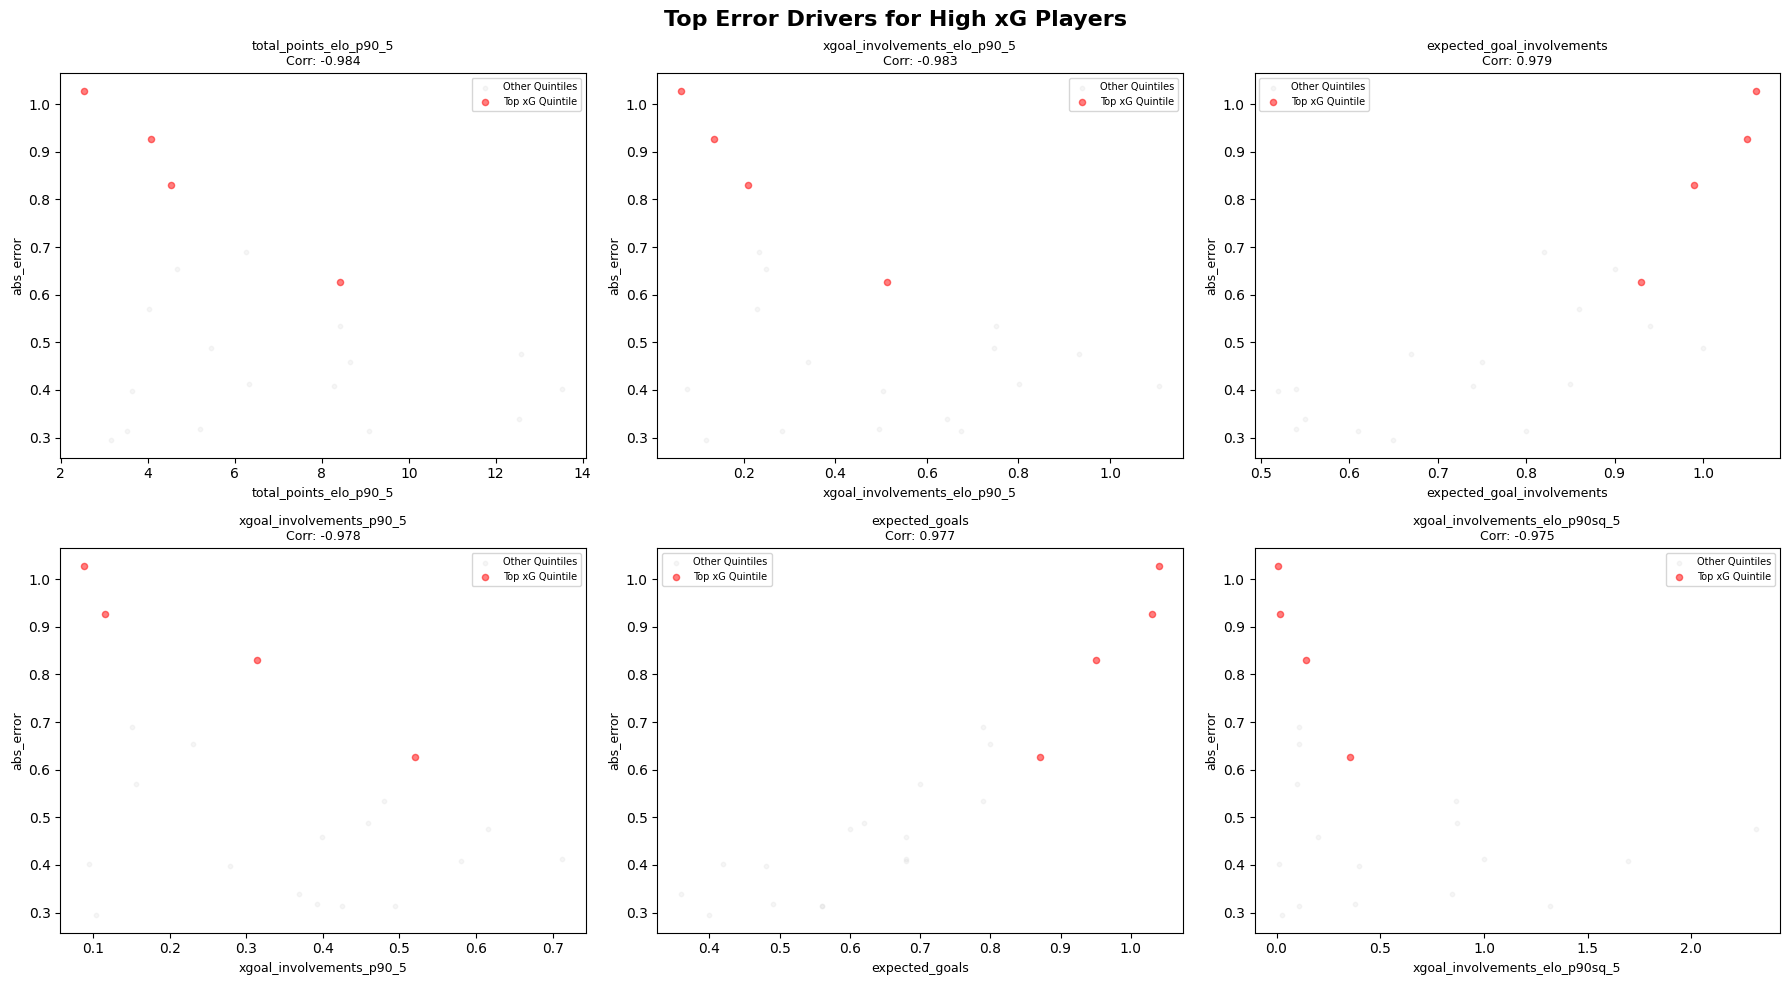


4. PREDICTION BIAS ANALYSIS

High xG Players:
  Over-predicted: 0 (0.0%)
  Under-predicted: 4 (100.0%)
  Mean Bias: -0.853

5. HIGH ERROR SUBGROUPS WITHIN TOP xG QUINTILE

Error by Position:
              mean  count
position                 
MID       0.853269      4

Error by Team Strength:
                   mean  count
team_strength                 
Weak           0.929582      2
Medium         0.626320      1
Strong         0.927591      1

Error by Opponent Strength:
                  mean  count
opp_strength                 
Weak          0.879370      2
Medium        1.028015      1
Strong        0.626320      1

Error by Home/Away:
              mean  count
was_home                 
false     0.927591      1
true      0.828495      3

6. SUGGESTED IMPROVEMENTS FOR HIGH xG PLAYERS

Recommendations:

1. ✓ Add INTERACTION term: 'total_points_elo_p90_5' × 'xgoal_involvements_elo_p90_5' (|Corr|: 0.950)


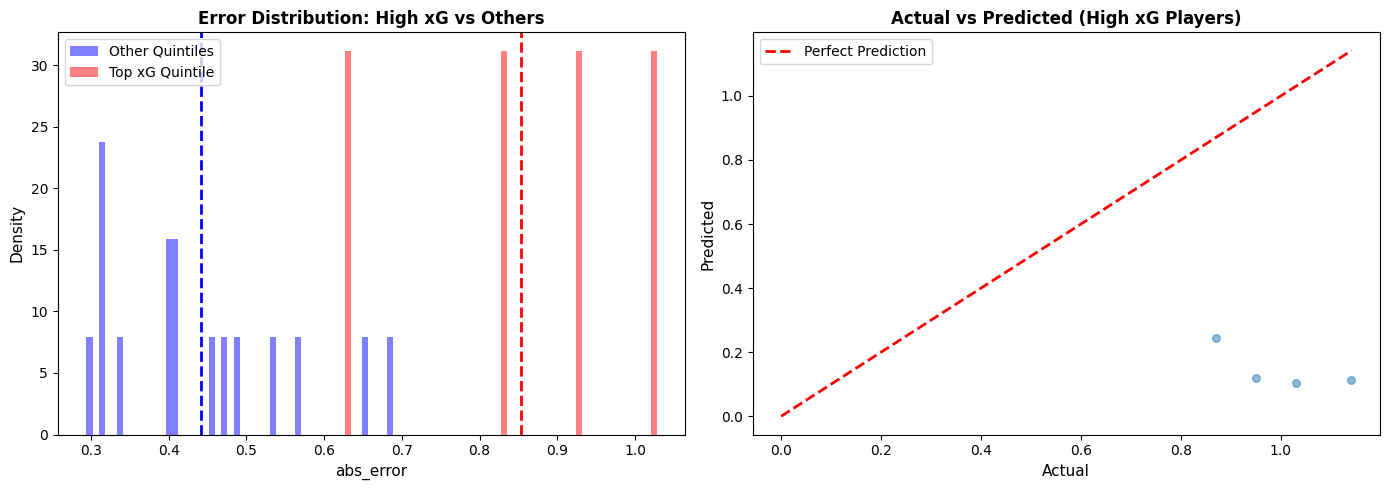

In [219]:
# USAGE:
results = analyze_high_xg_errors(MID_xG_errors, xg_col='expected_goals', error_col='abs_error')

Cleaned df size: 810/13902

Training Set Performance:
R² Score: 0.9305
RMSE: 9.5005
MAE: 7.0577

Test Set Performance:
R² Score: 0.4952
RMSE: 26.3268
MAE: 18.5596

Top 20 Feature Importances:
                                  feature  importance
                                minutes_3    0.426874
                            minutes_elo_3    0.101200
                                minutes_5    0.013010
                           bonus_p90sq_10    0.008725
    xgoal_involvements_x_defensive_cont_3    0.008009
                      xassists_elo_p90_10    0.007463
                         tackles_p90sq_10    0.007283
               defensive_cont_elo_p90sq_3    0.005060
                               xassists_3    0.004965
                  recoveries_elo_p90sq_10    0.004719
                       bonus_elo_p90sq_10    0.004302
                                bps_p90_5    0.004046
                       xgoals_conceded_10    0.004035
                        xassists_p90sq_at    0.00399

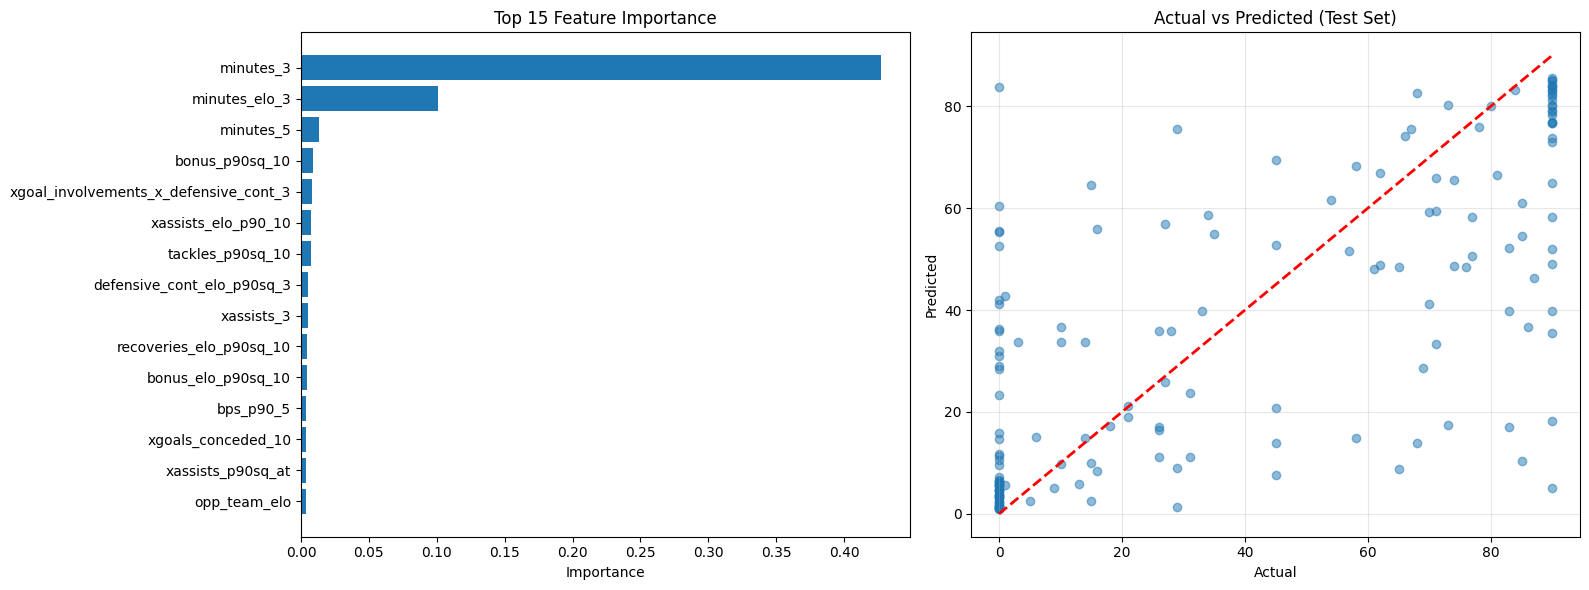

Cleaned df size: 3154/50011

Training Set Performance:
R² Score: 0.8380
RMSE: 15.2024
MAE: 11.7776

Test Set Performance:
R² Score: 0.5084
RMSE: 26.6284
MAE: 20.5706

Top 20 Feature Importances:
                                   feature  importance
                                 minutes_3    0.458956
                             minutes_elo_3    0.039742
                                    bps_10    0.010136
                              opp_team_elo    0.009111
                                 bps_elo_3    0.008161
                                     bps_3    0.007411
                                bps_elo_10    0.006722
                                 minutes_5    0.006711
                        total_points_elo_3    0.006464
    xgoal_involvements_x_defensive_cont_10    0.005457
     xgoal_involvements_x_defensive_cont_3    0.005253
                                  elo_diff    0.005112
xgoal_involvements_x_defensive_cont_p90_at    0.004983
                                min

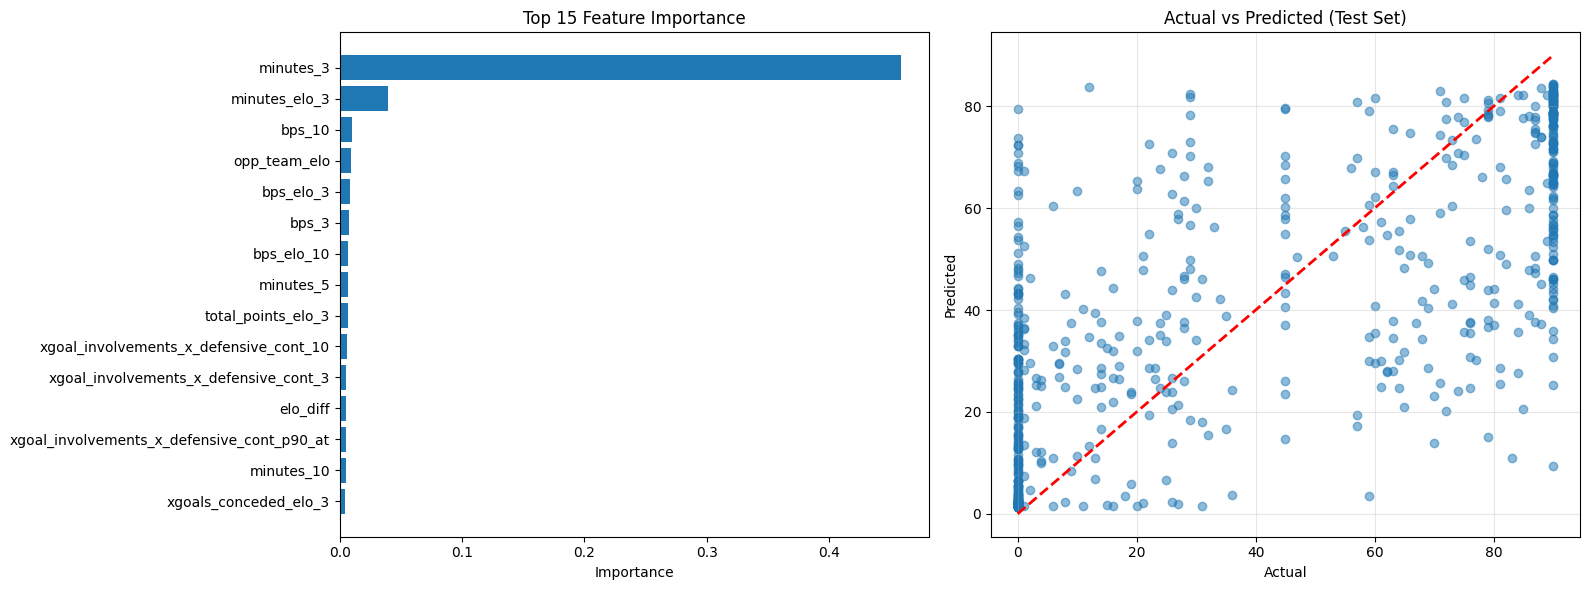

Cleaned df size: 2439/39301

Training Set Performance:
R² Score: 0.8518
RMSE: 16.1678
MAE: 11.9129

Test Set Performance:
R² Score: 0.5120
RMSE: 29.1153
MAE: 21.8228

Top 20 Feature Importances:
                    feature  importance
                  minutes_3    0.488350
              minutes_elo_3    0.020125
       opp_team_elo_p90sq_3    0.010131
         recoveries_p90sq_3    0.008914
                 minutes_10    0.007733
               opp_team_elo    0.007083
            opp_team_elo_10    0.006996
             opp_team_elo_5    0.006234
           minutes_p90sq_at    0.005962
               bps_p90sq_at    0.005707
     recoveries_elo_p90sq_3    0.005596
             opp_team_elo_3    0.004863
   xgoals_conceded_p90sq_at    0.004792
                   elo_diff    0.004630
        recoveries_p90sq_at    0.004574
                bps_p90sq_3    0.004424
           tackles_p90sq_at    0.004266
                cbi_p90sq_3    0.004143
xgoals_conceded_elo_p90sq_5    0.004112
     

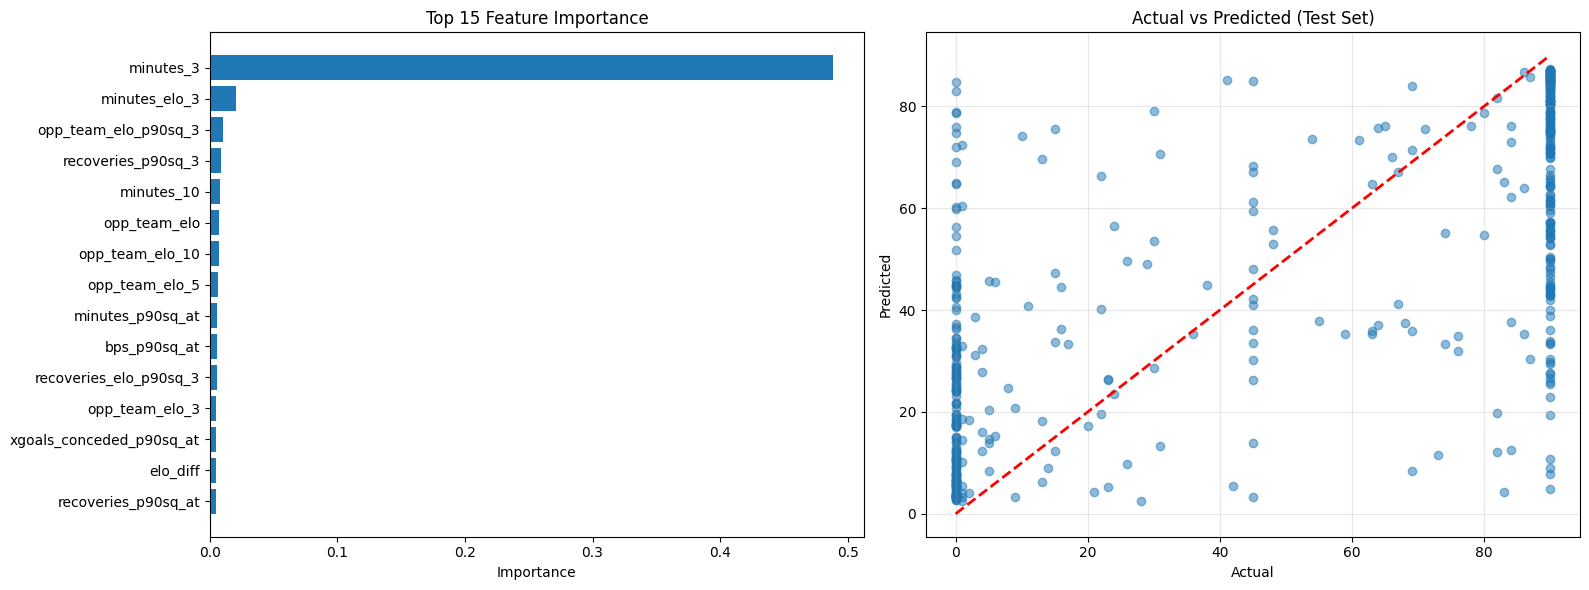

Cleaned df size: 441/8325

Training Set Performance:
R² Score: 0.9337
RMSE: 10.9173
MAE: 6.5928

Test Set Performance:
R² Score: 0.5982
RMSE: 25.9192
MAE: 15.3522

Top 20 Feature Importances:
               feature  importance
    recoveries_p90sq_3    0.268019
recoveries_elo_p90sq_3    0.093740
      team_elo_p90sq_3    0.048320
  opp_team_elo_p90sq_3    0.044632
     minutes_elo_p90_3    0.037740
opp_team_elo_elo_p90_3    0.033143
             minutes_3    0.029985
    team_elo_elo_p90_3    0.027122
        opp_team_elo_3    0.018922
           team_elo_10    0.015026
       opp_team_elo_10    0.014618
        opp_team_elo_5    0.012189
       bps_elo_p90sq_3    0.011932
     saves_elo_p90sq_3    0.010956
       cbi_elo_p90sq_5    0.008219
 clean_sheets_p90sq_at    0.008217
         minutes_elo_3    0.008104
            team_elo_3    0.008034
          opp_team_elo    0.007994
          bps_p90sq_at    0.007476


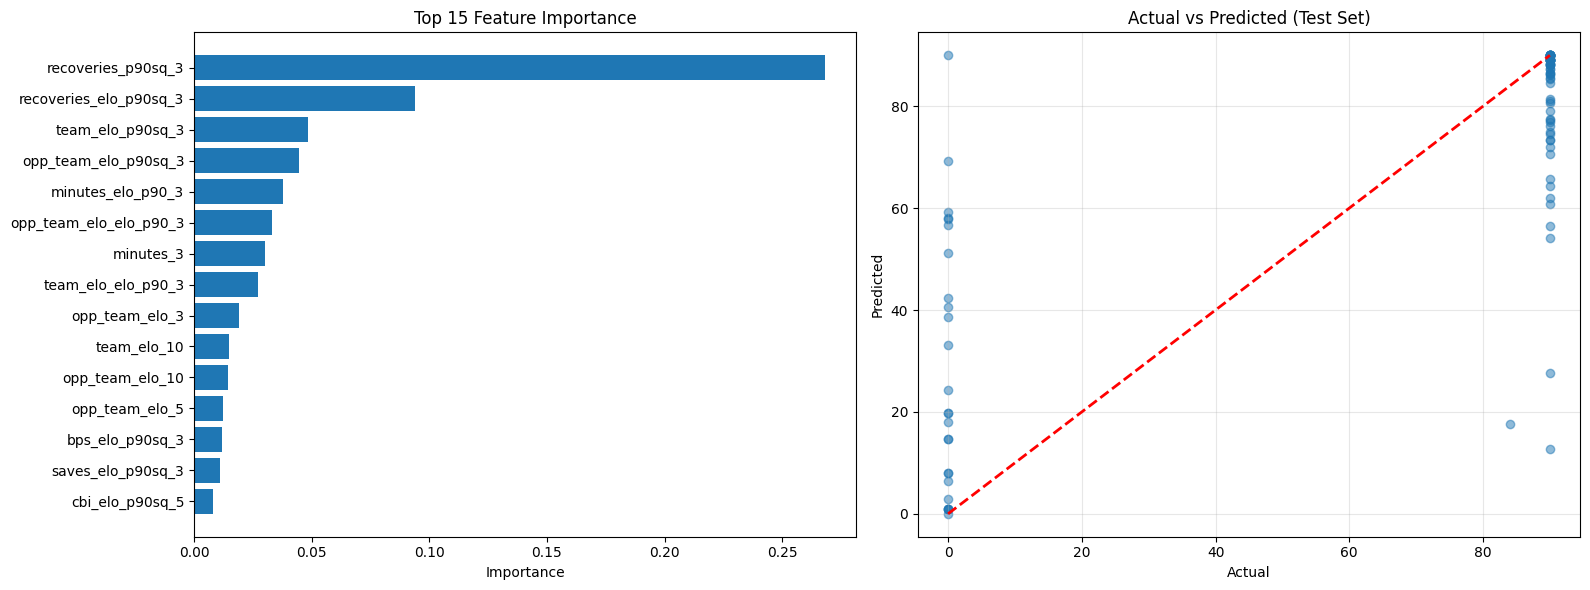

In [220]:
filtered = (df['player_season_minutes_total']>0)#&(df['total_points']<15)#&(df['minutes']>45)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[filtered],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[filtered],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 247/4192

Training Set Performance:
R² Score: 0.8464
RMSE: 0.1851
MAE: 0.1412

Test Set Performance:
R² Score: -0.0471
RMSE: 0.4511
MAE: 0.3463

Top 20 Feature Importances:
                              feature  importance
              goals_conceded_p90sq_at    0.030879
                 xgoal_involvements_5    0.029303
             xgoals_conceded_p90sq_at    0.028963
                             xgoals_5    0.023167
                       bonus_p90sq_at    0.021044
                       opp_team_elo_5    0.017113
                  minutes_elo_p90sq_3    0.016094
                  xassists_elo_p90_10    0.015946
                    minutes_elo_p90_5    0.014100
           xgoal_involvements_p90sq_3    0.013101
                    minutes_elo_p90_3    0.012679
                    xassists_p90sq_10    0.012376
                team_elo_elo_p90sq_10    0.012355
                      opp_team_elo_10    0.010711
              

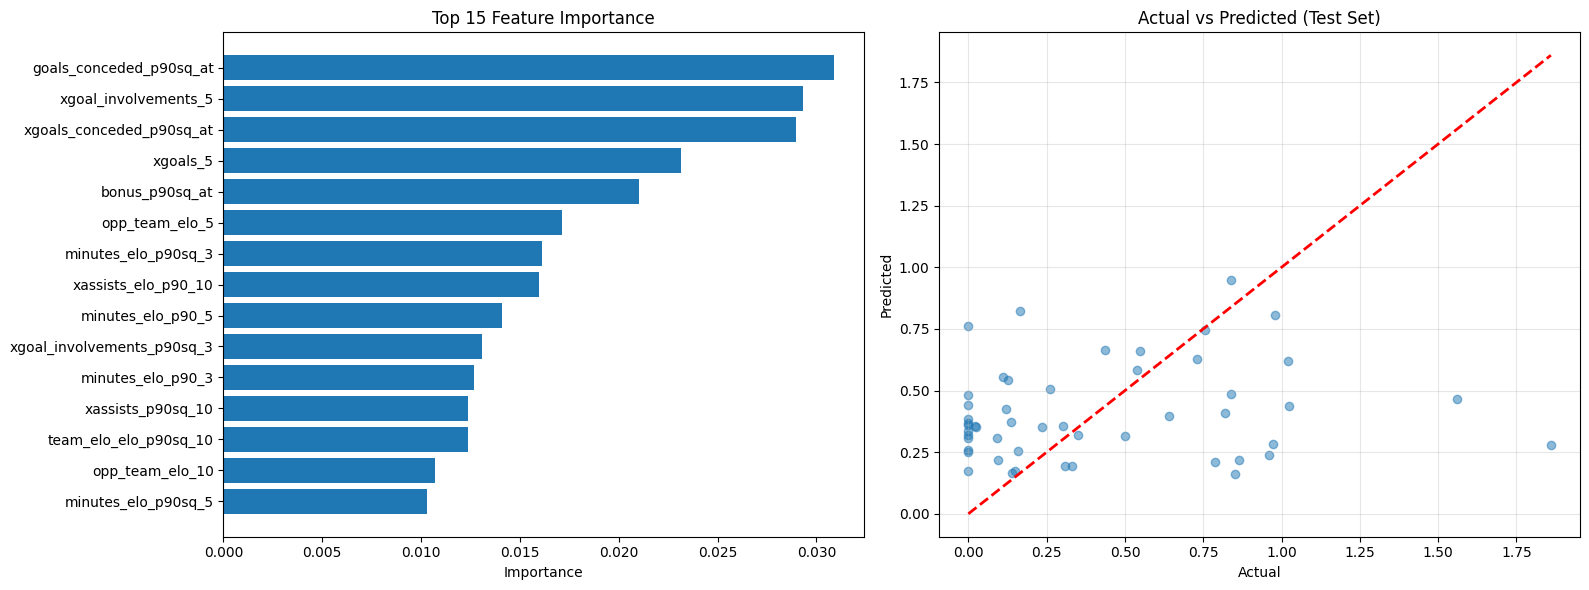

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 1224/17407

Training Set Performance:
R² Score: 0.7769
RMSE: 0.1118
MAE: 0.0816

Test Set Performance:
R² Score: 0.0029
RMSE: 0.2078
MAE: 0.1478

Top 20 Feature Importances:
                    feature  importance
               opp_team_elo    0.033440
          xassists_p90sq_at    0.024969
              xgoals_elo_10    0.023283
    goals_conceded_p90sq_10    0.021393
 xgoal_involvements_p90sq_5    0.015535
   xgoal_involvements_elo_5    0.013369
      goals_conceded_p90_10    0.012051
               xgoals_elo_5    0.011743
                   elo_diff    0.011058
                  xgoals_10    0.011051
xgoal_involvements_p90sq_10    0.010857
               bps_p90sq_10    0.010681
            opp_team_elo_10    0.010234
    goals_conceded_p90sq_at    0.010046
                 team_elo_5    0.009173
             bonus_p90sq_at    0.009000
         xgoals_conceded_10    0.008833
        xgoals_elo_p90sq_10    0.008713
   

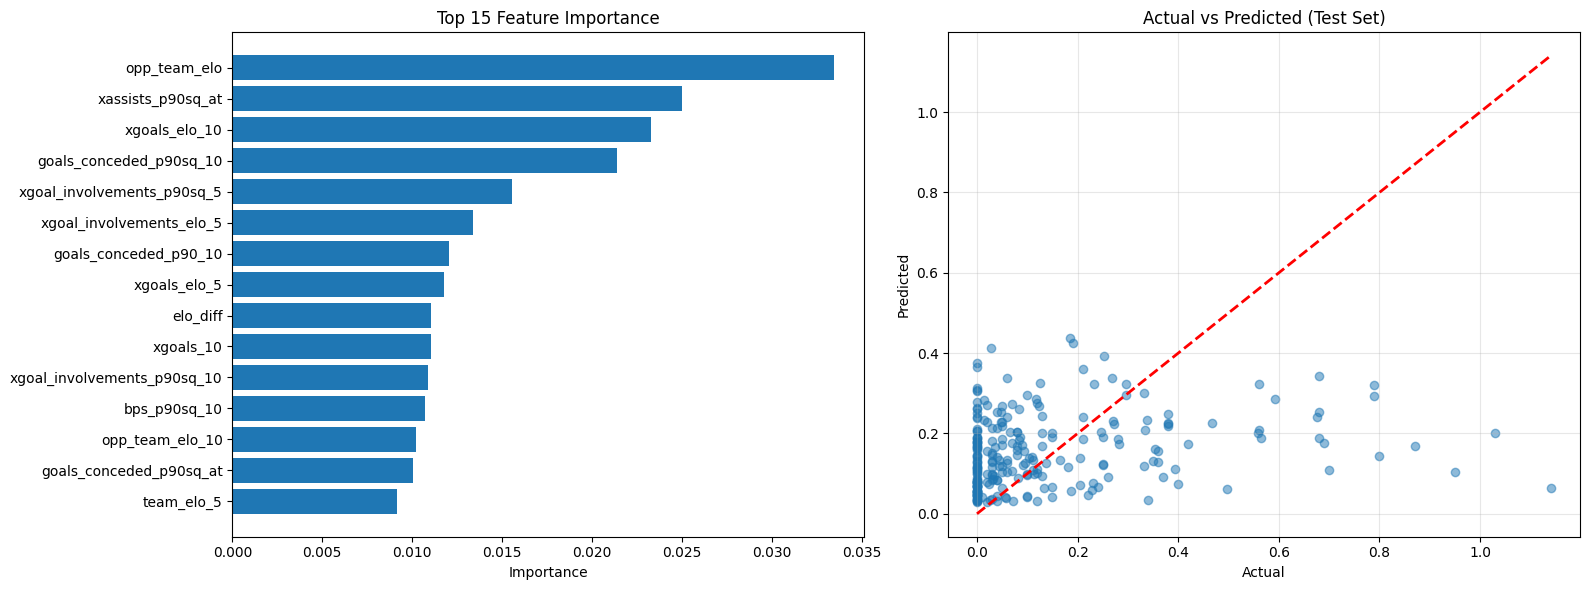

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 1094/15357

Training Set Performance:
R² Score: 0.7549
RMSE: 0.0622
MAE: 0.0418

Test Set Performance:
R² Score: -0.1926
RMSE: 0.1364
MAE: 0.0794

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.036729
              bps_elo_p90_3    0.020910
             bps_elo_p90_10    0.020345
      opp_team_elo_p90sq_at    0.019575
               bps_p90sq_at    0.018429
  xgoal_involvements_p90_10    0.018246
                 bps_elo_10    0.017719
                 bps_p90_10    0.015460
              bps_elo_p90_5    0.014843
                  bps_elo_5    0.014553
            opp_team_elo_10    0.013389
xgoal_involvements_p90sq_at    0.013139
             opp_team_elo_3    0.013039
               opp_team_elo    0.012371
            xgoals_p90sq_at    0.010708
        tackles_elo_p90sq_3    0.010434
            team_elo_elo_10    0.010138
          xassists_p90sq_at    0.009935
  

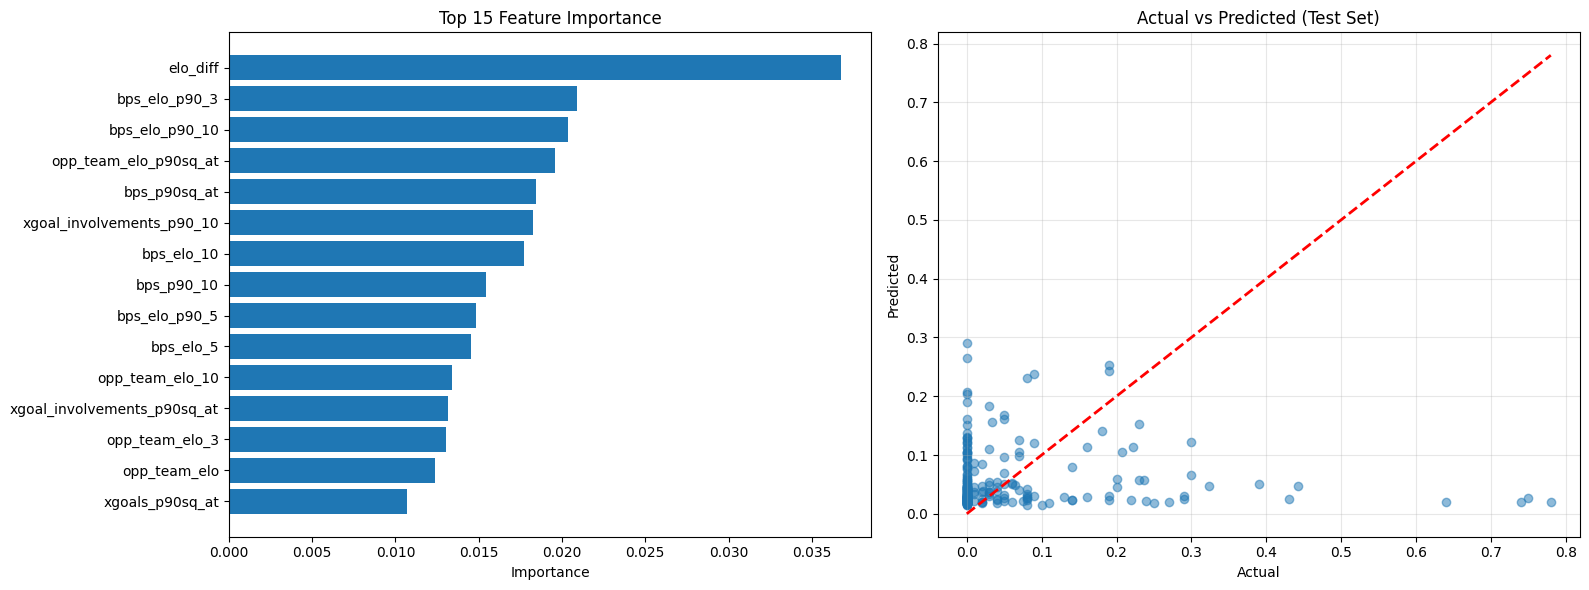

In [221]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 247/4192

Training Set Performance:
R² Score: 0.7916
RMSE: 0.0373
MAE: 0.0249

Test Set Performance:
R² Score: -0.6586
RMSE: 0.0657
MAE: 0.0488

Top 20 Feature Importances:
                    feature  importance
          goals_conceded_10    0.038861
            xgoals_p90sq_10    0.035831
     recoveries_elo_p90sq_3    0.033797
      opp_team_elo_p90sq_10    0.031395
             bonus_p90sq_at    0.028418
                   elo_diff    0.028308
               opp_team_elo    0.022234
xgoal_involvements_p90sq_10    0.019880
    goals_conceded_p90sq_at    0.019013
         clean_sheets_p90_3    0.018796
      xgoals_conceded_elo_3    0.015293
             opp_team_elo_3    0.012433
         clean_sheets_elo_3    0.012324
      total_points_p90sq_10    0.011390
         team_elo_elo_p90_3    0.010977
     xgoals_conceded_p90_10    0.010839
  total_points_elo_p90sq_10    0.009246
       tackles_elo_p90sq_10    0.009115
  

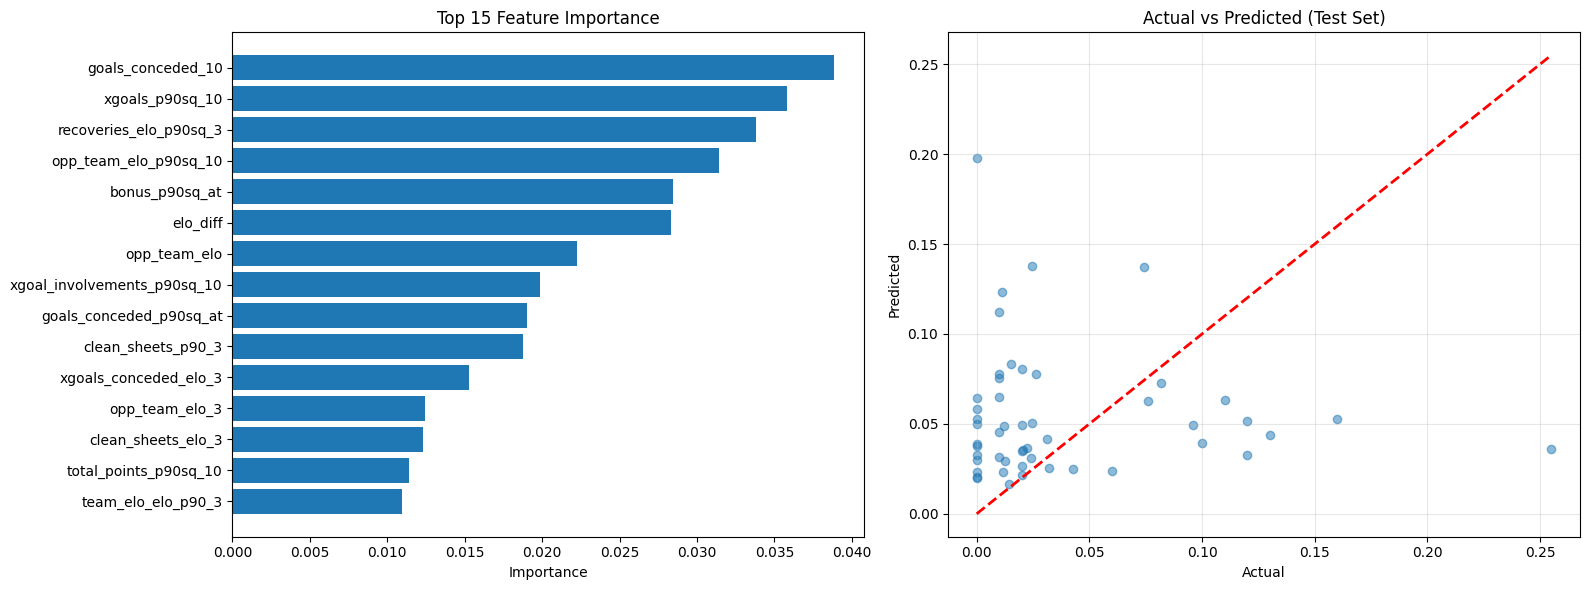

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 1224/17407

Training Set Performance:
R² Score: 0.7630
RMSE: 0.0739
MAE: 0.0555

Test Set Performance:
R² Score: -0.0080
RMSE: 0.1408
MAE: 0.1016

Top 20 Feature Importances:
                                   feature  importance
                              opp_team_elo    0.037295
                               xassists_10    0.026307
                                  elo_diff    0.021239
                     xassists_elo_p90sq_10    0.020712
                 xgoal_involvements_elo_10    0.020575
                                xassists_5    0.014653
                              cbi_p90sq_10    0.014590
                            xassists_elo_3    0.014284
                 xgoals_conceded_elo_p90_3    0.012541
                                    bps_10    0.012333
                       xassists_elo_p90_10    0.009300
                           xassists_elo_10    0.008997
                         xassists_p90sq_at   

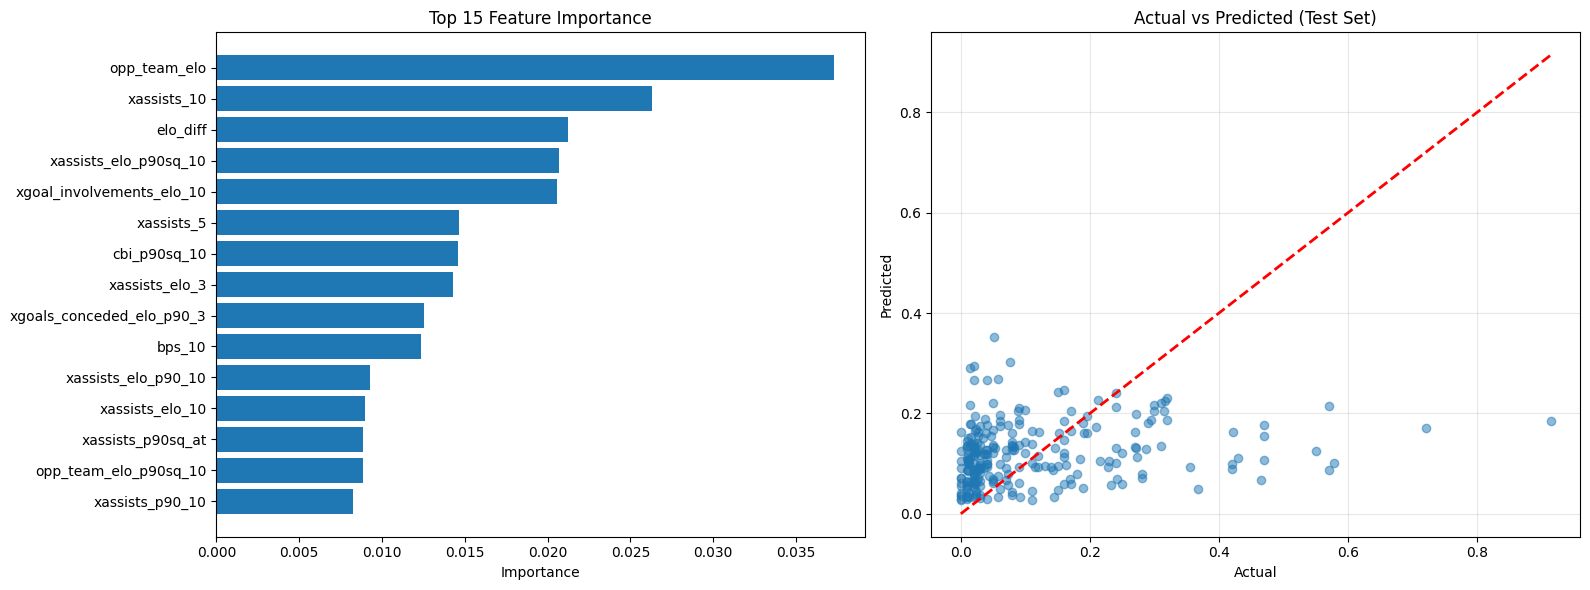

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 1094/15357

Training Set Performance:
R² Score: 0.7747
RMSE: 0.0511
MAE: 0.0350

Test Set Performance:
R² Score: -0.2363
RMSE: 0.0944
MAE: 0.0630

Top 20 Feature Importances:
                   feature  importance
         xassists_p90sq_at    0.040208
              opp_team_elo    0.036110
       recoveries_p90sq_at    0.027293
     total_points_p90sq_at    0.025516
           xassists_p90_10    0.022830
            total_points_5    0.017878
           total_points_10    0.015776
         xgoals_conceded_3    0.013586
goals_conceded_elo_p90sq_3    0.012879
           tackles_p90sq_3    0.011319
                     bps_5    0.010534
            opp_team_elo_5    0.010316
                  elo_diff    0.010201
            bonus_p90sq_10    0.009387
        recoveries_p90sq_3    0.008705
              bps_p90sq_10    0.008673
      total_points_p90sq_3    0.008598
         team_elo_p90sq_at    0.008380
          bonus_elo

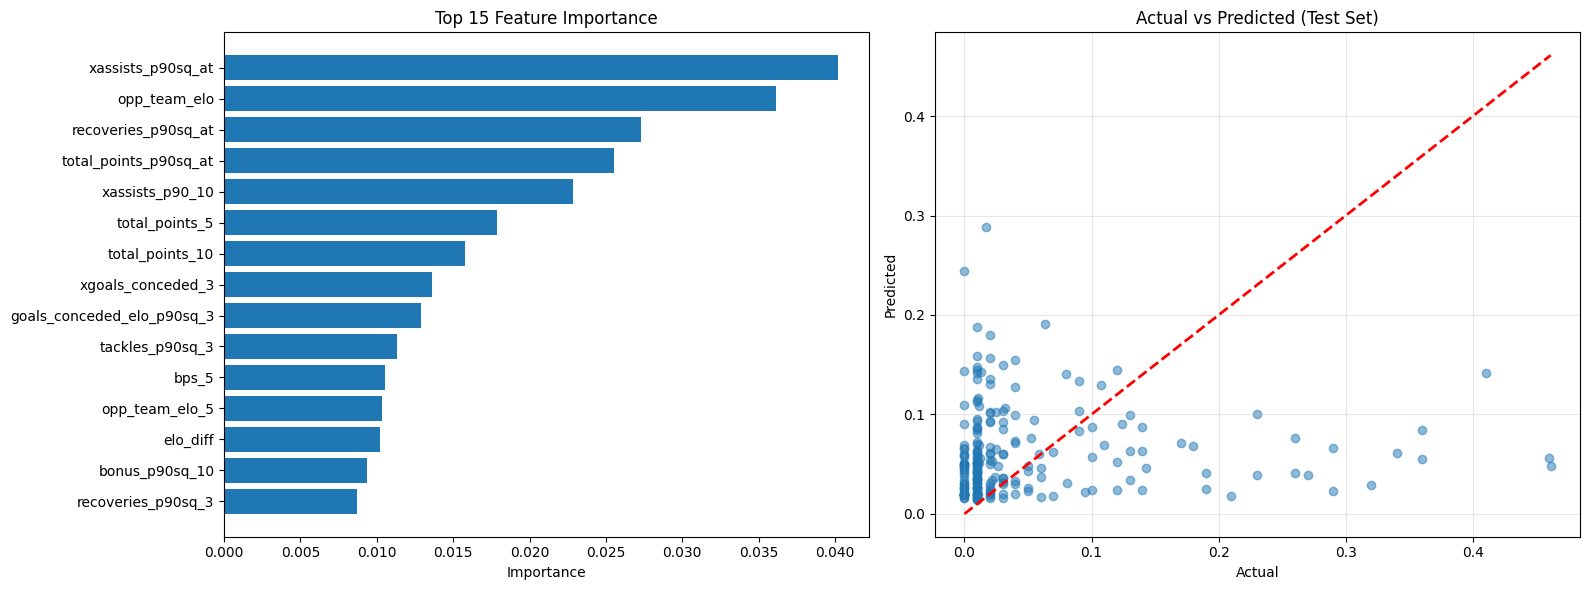

In [222]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 247/4192

Training Set Performance:
R² Score: 0.8372
RMSE: 0.3200
MAE: 0.2551

Test Set Performance:
R² Score: 0.0866
RMSE: 0.7629
MAE: 0.6295

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.077687
              opp_team_elo    0.031543
            opp_team_elo_3    0.031432
      opp_team_elo_p90sq_3    0.030769
         team_elo_p90sq_at    0.026874
                team_elo_3    0.015967
      goals_conceded_elo_3    0.014790
          team_elo_p90sq_5    0.011976
       recoveries_p90sq_at    0.011297
          tackles_p90sq_at    0.010651
            opp_team_elo_5    0.010287
goals_conceded_elo_p90sq_3    0.010164
           opp_team_elo_10    0.009772
        clean_sheets_elo_3    0.009675
                xassists_3    0.009359
            xassists_elo_3    0.009196
    defensive_cont_p90sq_5    0.008572
     xgoals_conceded_p90_3    0.008433
           bps

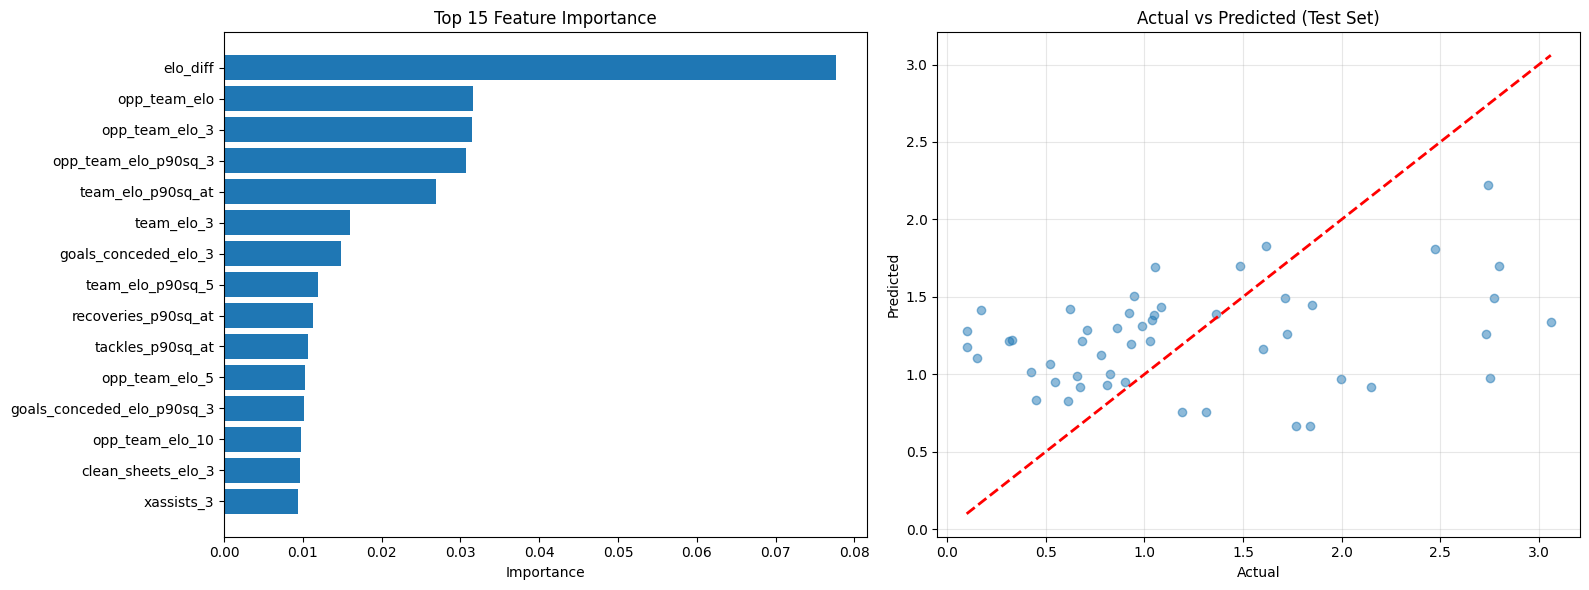

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 1224/17407

Training Set Performance:
R² Score: 0.8418
RMSE: 0.3104
MAE: 0.2549

Test Set Performance:
R² Score: 0.4067
RMSE: 0.6051
MAE: 0.4745

Top 20 Feature Importances:
                                  feature  importance
                                 elo_diff    0.188264
                             opp_team_elo    0.058232
                           opp_team_elo_3    0.051546
                                 team_elo    0.035666
                          opp_team_elo_10    0.025746
                               team_elo_3    0.023179
                           opp_team_elo_5    0.022126
                               team_elo_5    0.015081
                          team_elo_elo_10    0.013395
                           team_elo_elo_3    0.012219
                       opp_team_elo_elo_5    0.009580
                           team_elo_elo_5    0.009265
                       opp_team_elo_elo_3    0.0084

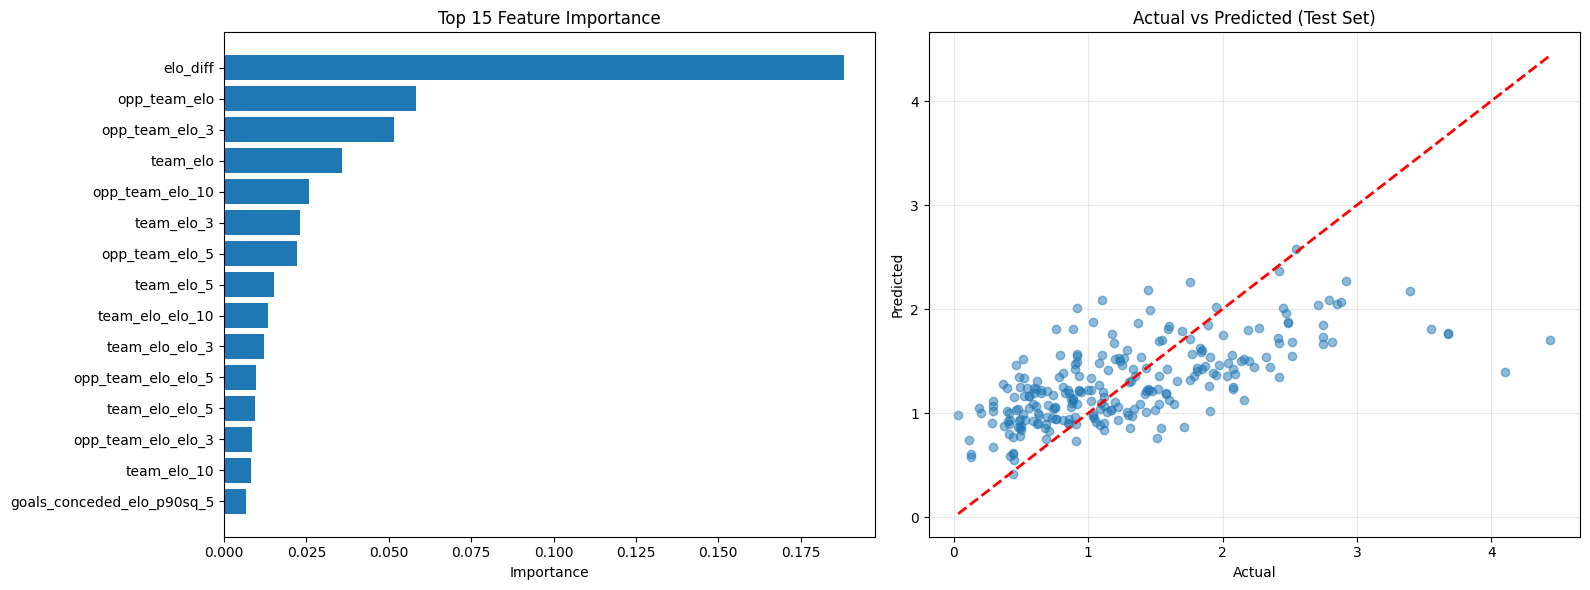

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 1094/15357

Training Set Performance:
R² Score: 0.8711
RMSE: 0.2942
MAE: 0.2348

Test Set Performance:
R² Score: 0.4039
RMSE: 0.6090
MAE: 0.4762

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.186276
             opp_team_elo_3    0.057849
               opp_team_elo    0.051914
                 team_elo_3    0.027293
                   team_elo    0.026383
             opp_team_elo_5    0.022384
                 team_elo_5    0.016267
            opp_team_elo_10    0.013656
        minutes_elo_p90sq_5    0.013004
                team_elo_10    0.010684
   xgoals_conceded_p90sq_10    0.010350
    xgoals_conceded_p90sq_3    0.009839
     xgoals_conceded_p90_10    0.009366
         opp_team_elo_elo_3    0.009213
          minutes_elo_p90_5    0.008989
             team_elo_elo_5    0.008932
       opp_team_elo_p90sq_3    0.007994
    goals_conceded_p90sq_10    0.

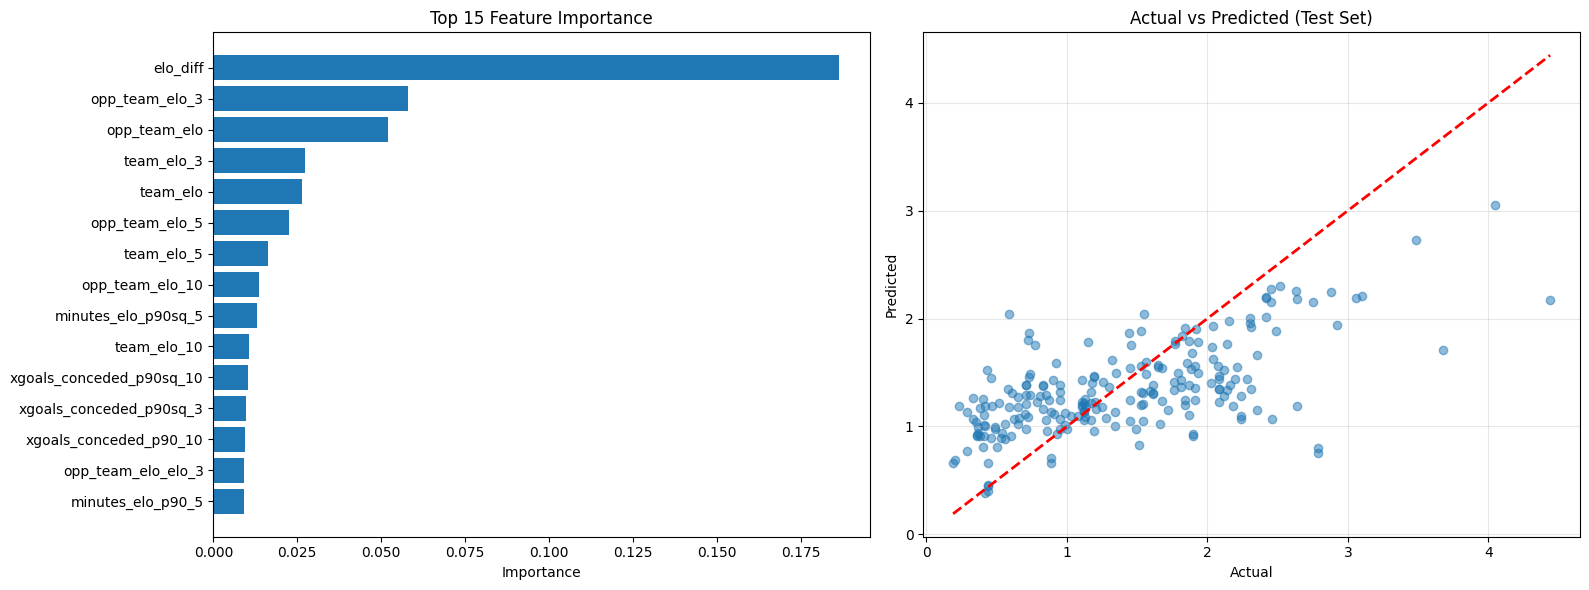

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 270/3737

Training Set Performance:
R² Score: 0.8559
RMSE: 0.3225
MAE: 0.2580

Test Set Performance:
R² Score: -0.4067
RMSE: 0.7472
MAE: 0.5891

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.213997
             opp_team_elo_3    0.030584
               opp_team_elo    0.028215
          saves_elo_p90sq_3    0.026968
            opp_team_elo_10    0.025337
             opp_team_elo_5    0.015878
         recoveries_p90sq_3    0.015656
                 team_elo_5    0.015611
        recoveries_p90sq_at    0.013743
xgoals_conceded_elo_p90sq_5    0.012683
               bps_p90sq_at    0.012226
    xgoals_conceded_p90sq_5    0.012079
               cbi_p90sq_10    0.011785
      opp_team_elo_p90sq_10    0.011599
      xgoals_conceded_elo_5    0.011449
           team_elo_p90sq_3    0.011160
     recoveries_elo_p90sq_3    0.010655
           cbi_elo_p90sq_10    0.01

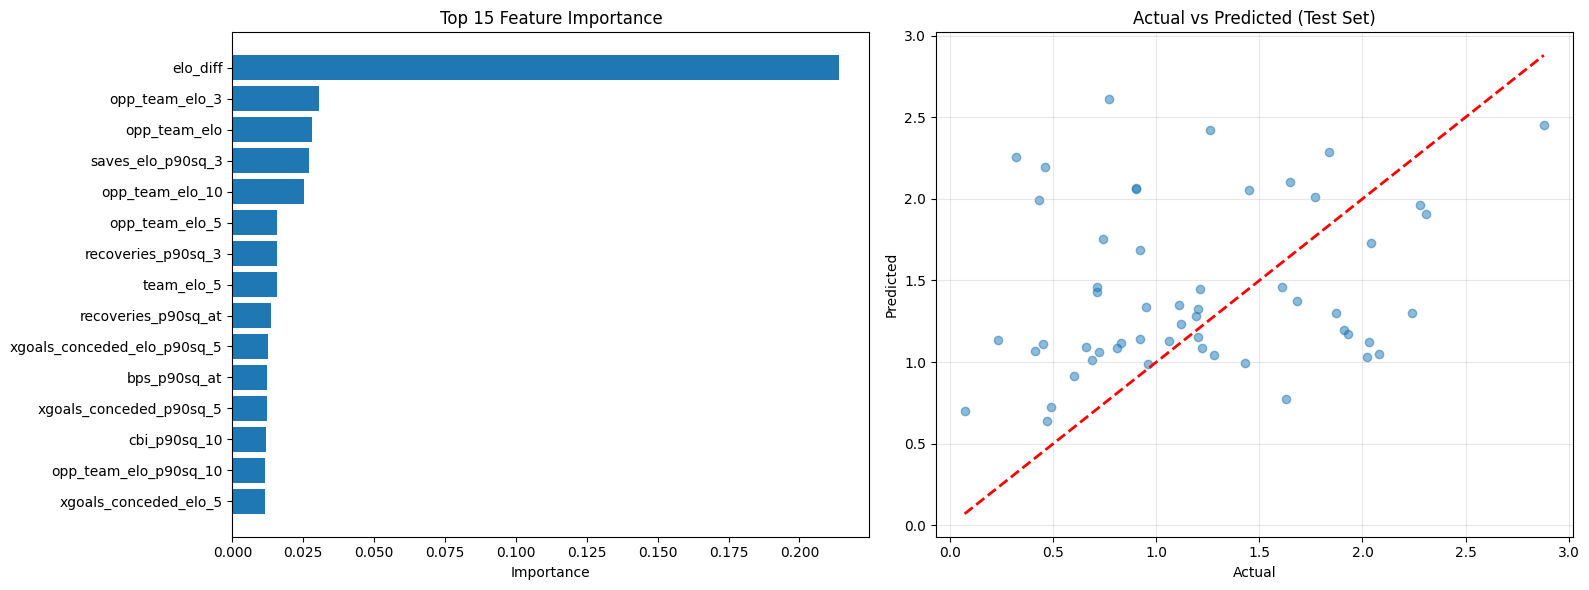

In [223]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 247/4192

Training Set Performance:
R² Score: 0.8088
RMSE: 7.8475
MAE: 6.0388

Test Set Performance:
R² Score: -0.0254
RMSE: 19.9805
MAE: 15.0463

Top 20 Feature Importances:
                  feature  importance
        minutes_elo_p90_3    0.050684
          cbi_elo_p90sq_3    0.024446
        minutes_elo_p90_5    0.021865
      minutes_elo_p90sq_5    0.019268
                 team_elo    0.019065
      xassists_elo_p90_10    0.019020
     minutes_elo_p90sq_10    0.017636
    goals_conceded_p90_10    0.016794
    clean_sheets_p90sq_10    0.016172
  goals_conceded_p90sq_10    0.014784
      minutes_elo_p90sq_3    0.014213
          xgoals_p90sq_at    0.014068
        xassists_p90sq_10    0.011648
        xassists_p90sq_at    0.010313
             opp_team_elo    0.009961
               team_elo_3    0.009333
goals_conceded_elo_p90_10    0.009041
       opp_team_elo_elo_3    0.008908
           team_elo_elo_3    0.008895
            

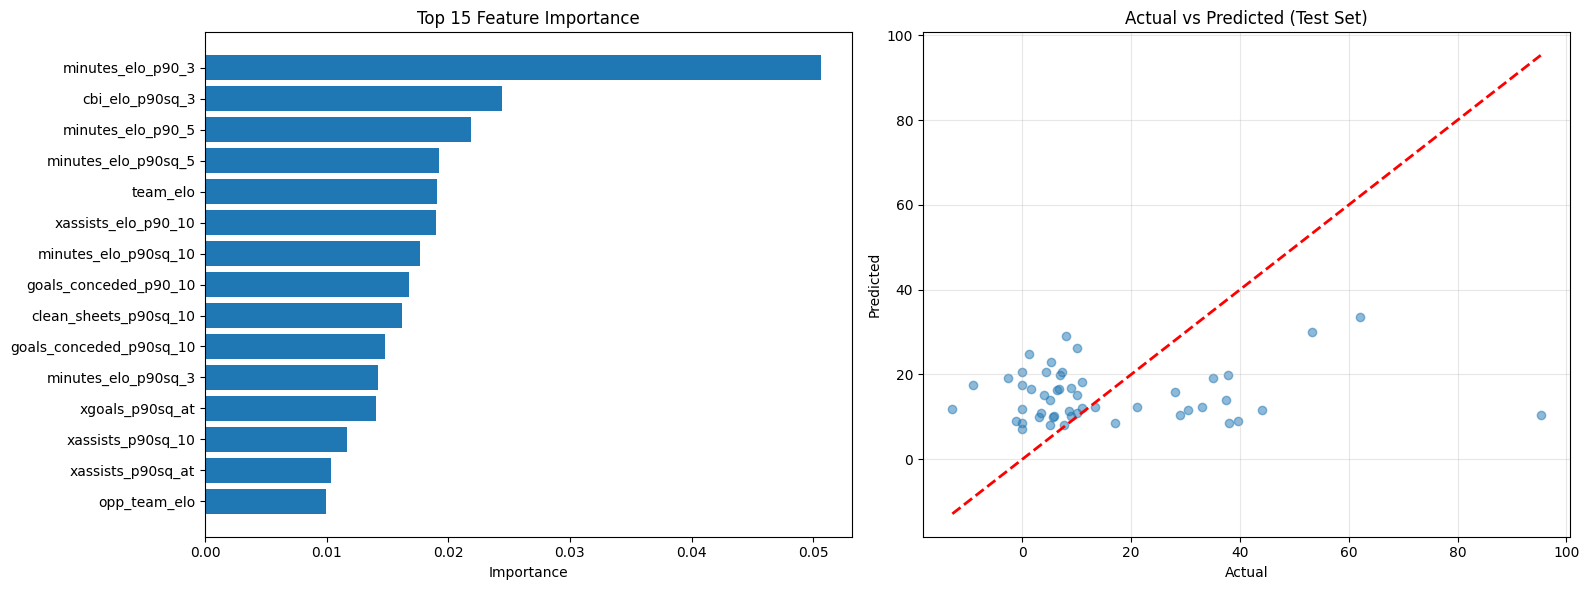

target=bps_per90, MID_bps_predictor
Cleaned df size: 1224/17407

Training Set Performance:
R² Score: 0.6662
RMSE: 6.9217
MAE: 5.4763

Test Set Performance:
R² Score: -0.1090
RMSE: 11.4629
MAE: 8.3107

Top 20 Feature Importances:
                                   feature  importance
                                  elo_diff    0.073789
xgoal_involvements_x_defensive_cont_p90_10    0.018283
xgoal_involvements_x_defensive_cont_p90_at    0.011393
                     opp_team_elo_p90sq_10    0.010434
                     total_points_p90sq_at    0.009860
                         xgoals_conceded_5    0.009782
                 opp_team_elo_elo_p90sq_10    0.009639
                  clean_sheets_elo_p90sq_5    0.009631
     xgoal_involvements_x_defensive_cont_3    0.008815
                    goals_conceded_p90sq_5    0.008580
                      opp_team_elo_p90sq_5    0.008248
                              opp_team_elo    0.008041
                    recoveries_elo_p90sq_3    0.008021
 

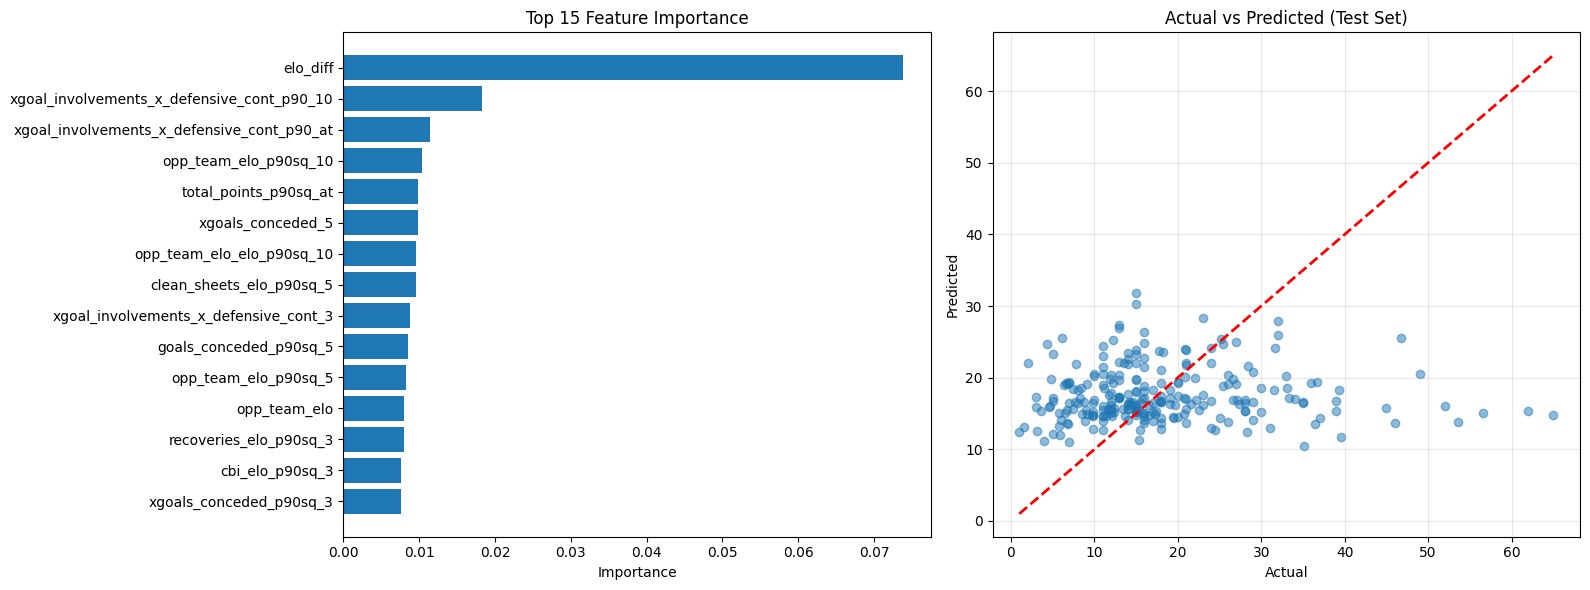

target=bps_per90, DEF_bps_predictor
Cleaned df size: 1094/15357

Training Set Performance:
R² Score: 0.8240
RMSE: 5.3414
MAE: 4.2364

Test Set Performance:
R² Score: 0.1727
RMSE: 11.1542
MAE: 8.5496

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.137209
            opp_team_elo_5    0.025635
           opp_team_elo_10    0.024174
              opp_team_elo    0.020417
            team_elo_elo_5    0.016016
            team_elo_elo_3    0.013716
            opp_team_elo_3    0.013692
               team_elo_10    0.013115
                team_elo_3    0.009192
             bps_elo_p90_3    0.009111
                team_elo_5    0.009058
              bps_p90sq_at    0.008596
        opp_team_elo_elo_5    0.008540
      goals_conceded_elo_3    0.007724
goals_conceded_elo_p90sq_3    0.007650
          tackles_p90sq_10    0.007441
                 bps_elo_5    0.007402
      goals_conceded_elo_5    0.007212
                bps_p90_10    0

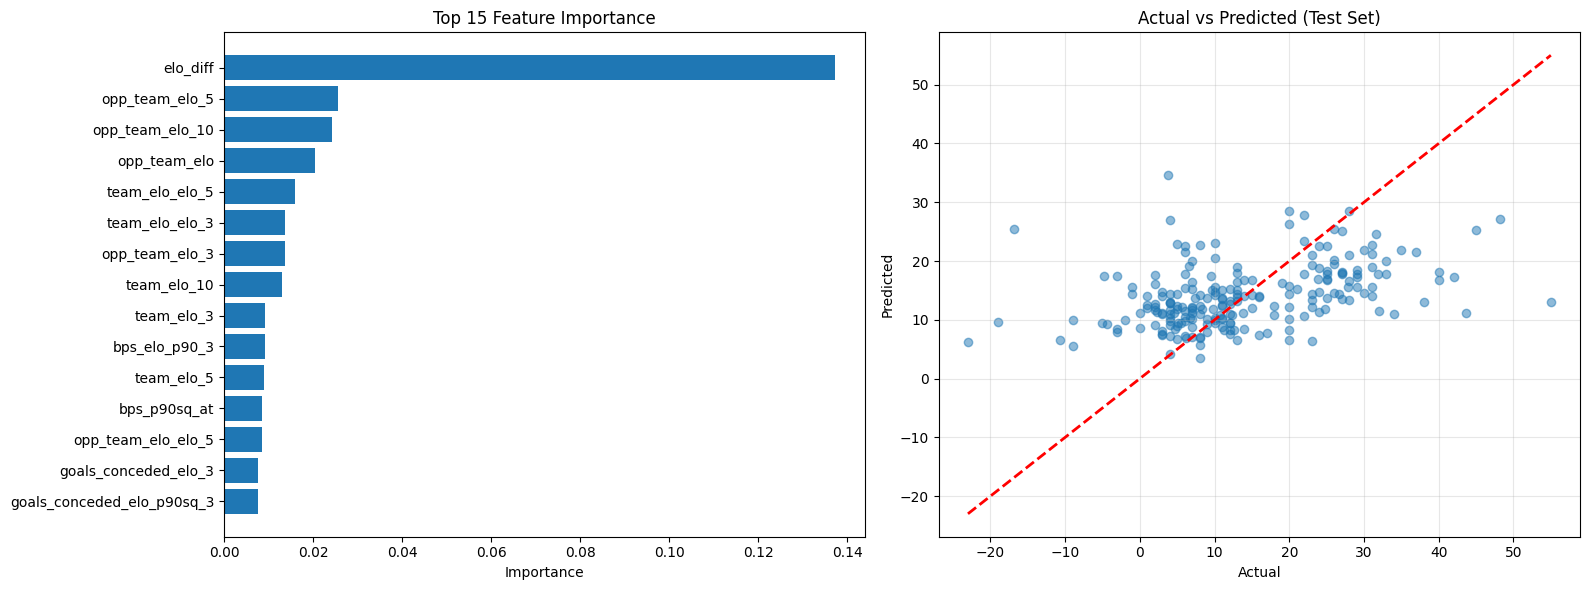

target=bps_per90, GK_bps_predictor
Cleaned df size: 270/3737

Training Set Performance:
R² Score: 0.8427
RMSE: 3.9208
MAE: 3.1810

Test Set Performance:
R² Score: -0.0904
RMSE: 11.1141
MAE: 9.3459

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.026151
             opp_team_elo_3    0.025102
 goals_conceded_elo_p90sq_5    0.022241
             opp_team_elo_5    0.020910
    xgoals_conceded_p90sq_3    0.019103
               cbi_p90sq_at    0.019077
         recoveries_p90sq_3    0.016400
      opp_team_elo_p90sq_10    0.016242
xgoals_conceded_elo_p90sq_3    0.015990
         saves_elo_p90sq_10    0.015897
               opp_team_elo    0.015272
            opp_team_elo_10    0.015048
         recoveries_p90sq_5    0.014281
       total_points_p90sq_3    0.014013
            cbi_elo_p90sq_5    0.014009
 goals_conceded_elo_p90sq_3    0.013672
goals_conceded_elo_p90sq_10    0.012994
         team_elo_elo_p90_5    0.012971
       opp_tea

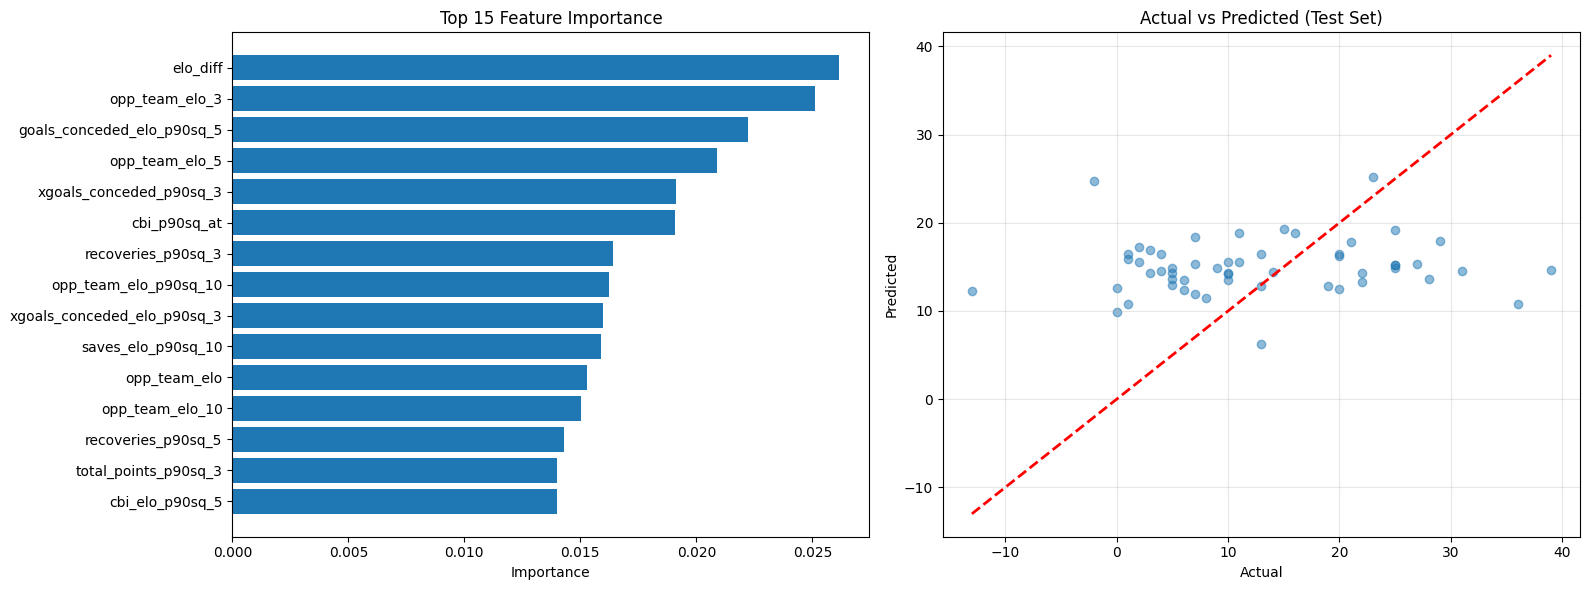

In [224]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>500)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 297/3899

Training Set Performance:
R² Score: 0.8509
RMSE: 0.6662
MAE: 0.5208

Test Set Performance:
R² Score: -0.2399
RMSE: 1.6677
MAE: 1.4103

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.078948
             opp_team_elo_3    0.036601
      team_elo_elo_p90sq_10    0.028372
               opp_team_elo    0.027004
                cbi_p90sq_5    0.022782
             opp_team_elo_5    0.020744
           bps_elo_p90sq_10    0.018965
            opp_team_elo_10    0.017141
                 team_elo_3    0.013758
      opp_team_elo_p90sq_10    0.012685
       opp_team_elo_p90sq_5    0.012123
                   team_elo    0.010933
          team_elo_p90sq_10    0.010813
    goals_conceded_p90sq_at    0.010168
 goals_conceded_elo_p90sq_5    0.010058
               cbi_p90sq_10    0.009903
               bps_p90sq_10    0.008777
          saves_elo_p90sq_3    0.008640
xgoals_conc

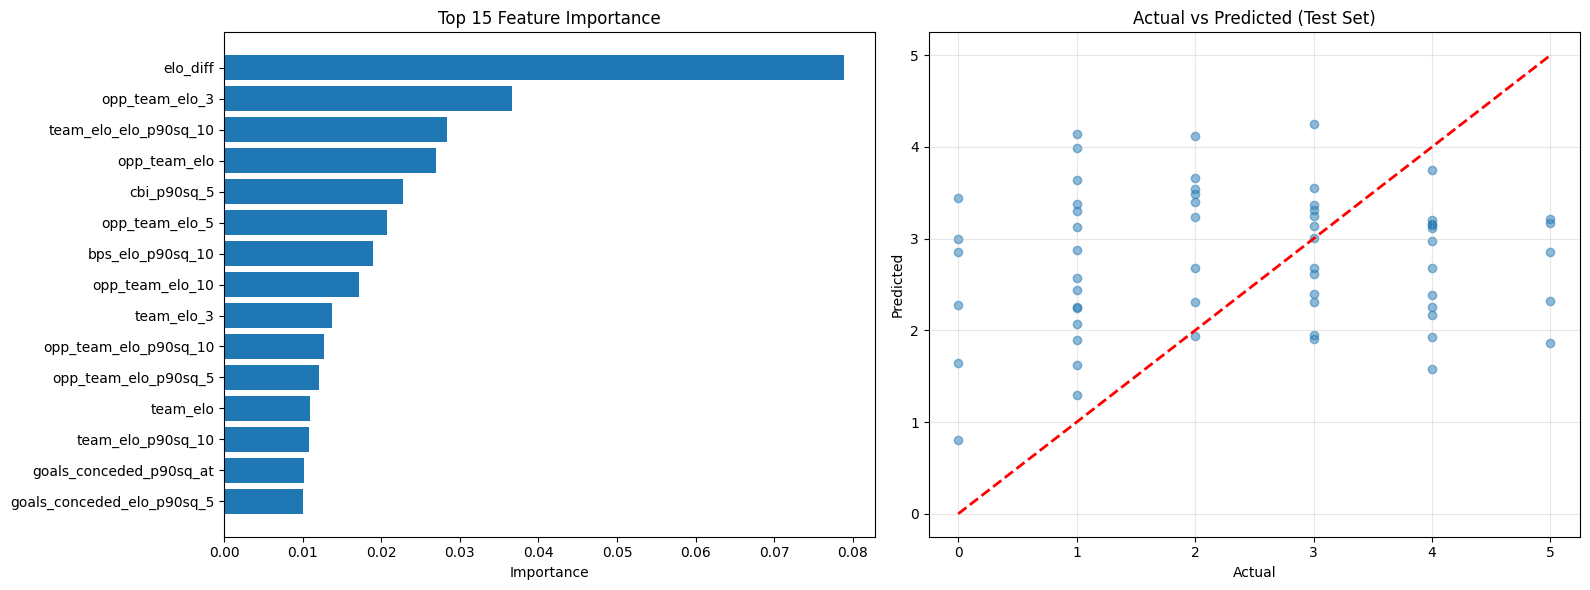

In [225]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
    data=df[filtered],
    target='saves_per90',
    positions={'GK'})
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 329/4802

Training Set Performance:
R² Score: 0.8274
RMSE: 1.1536
MAE: 0.8867

Test Set Performance:
R² Score: -0.1031
RMSE: 2.9983
MAE: 1.9999

Top 20 Feature Importances:
                                  feature  importance
                      minutes_elo_p90sq_5    0.021446
                           opp_team_elo_5    0.018454
                                 team_elo    0.016643
                    goals_conceded_p90_10    0.016435
                clean_sheets_elo_p90sq_10    0.015508
                        xassists_p90sq_at    0.015296
                           bonus_p90sq_at    0.013819
                          opp_team_elo_10    0.012495
                        xgoals_conceded_3    0.011275
                         recoveries_elo_3    0.011152
                           opp_team_elo_3    0.010833
                         xassists_p90sq_5    0.010399
                  goals_conceded_p90sq_at    0.009

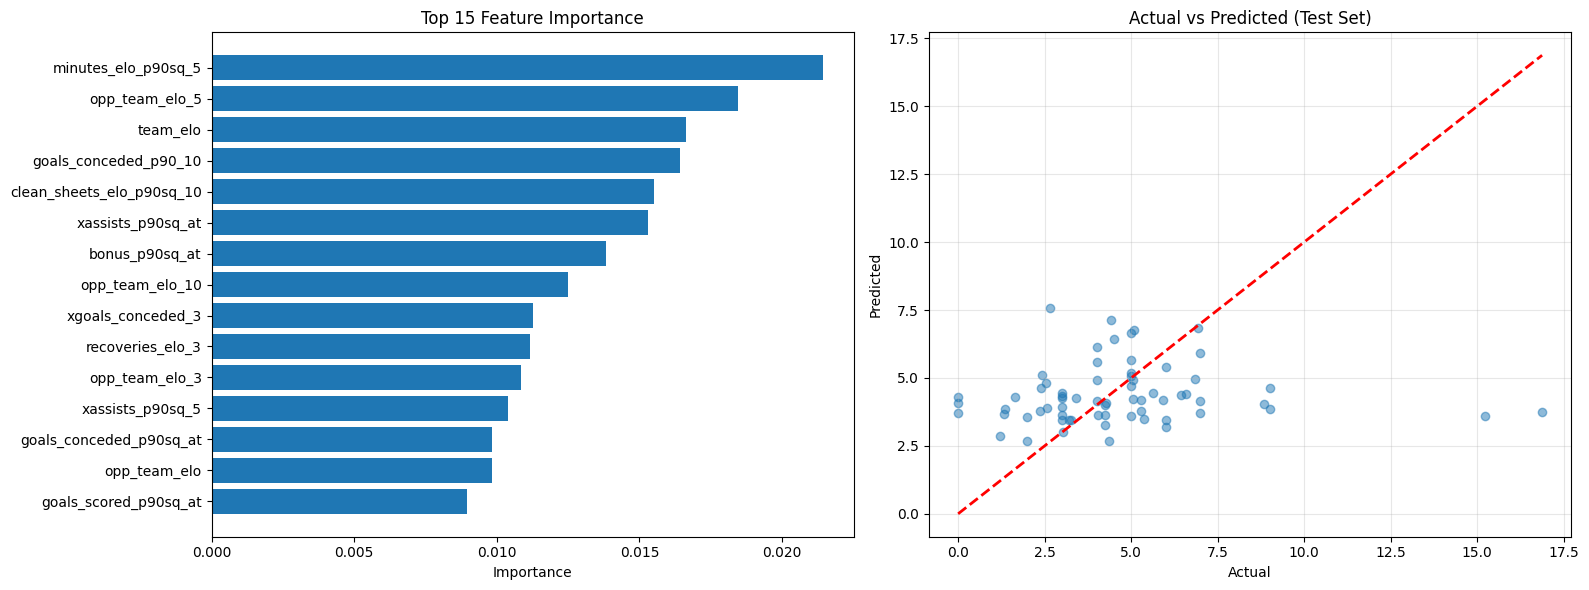

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 1540/19803

Training Set Performance:
R² Score: 0.7988
RMSE: 1.8575
MAE: 1.4979

Test Set Performance:
R² Score: 0.0749
RMSE: 3.8778
MAE: 3.0159

Top 20 Feature Importances:
                    feature  importance
                 cbi_p90_10    0.069260
                 tackles_at    0.022039
           tackles_p90sq_10    0.017920
      goals_scored_p90sq_at    0.012704
      defensive_cont_p90_10    0.011989
                     cbi_at    0.010477
     defensive_cont_p90sq_5    0.009821
              xgoals_p90_10    0.009655
xgoal_involvements_p90sq_10    0.008728
      total_points_p90sq_10    0.008361
                   elo_diff    0.008316
          xgoals_elo_p90_10    0.007951
             tackles_elo_10    0.007694
    defensive_cont_p90sq_10    0.007685
            xgoals_p90sq_at    0.007654
               opp_team_elo    0.007466
          xassists_p90sq_at    0.007234
  total_points_elo_p90sq_10    

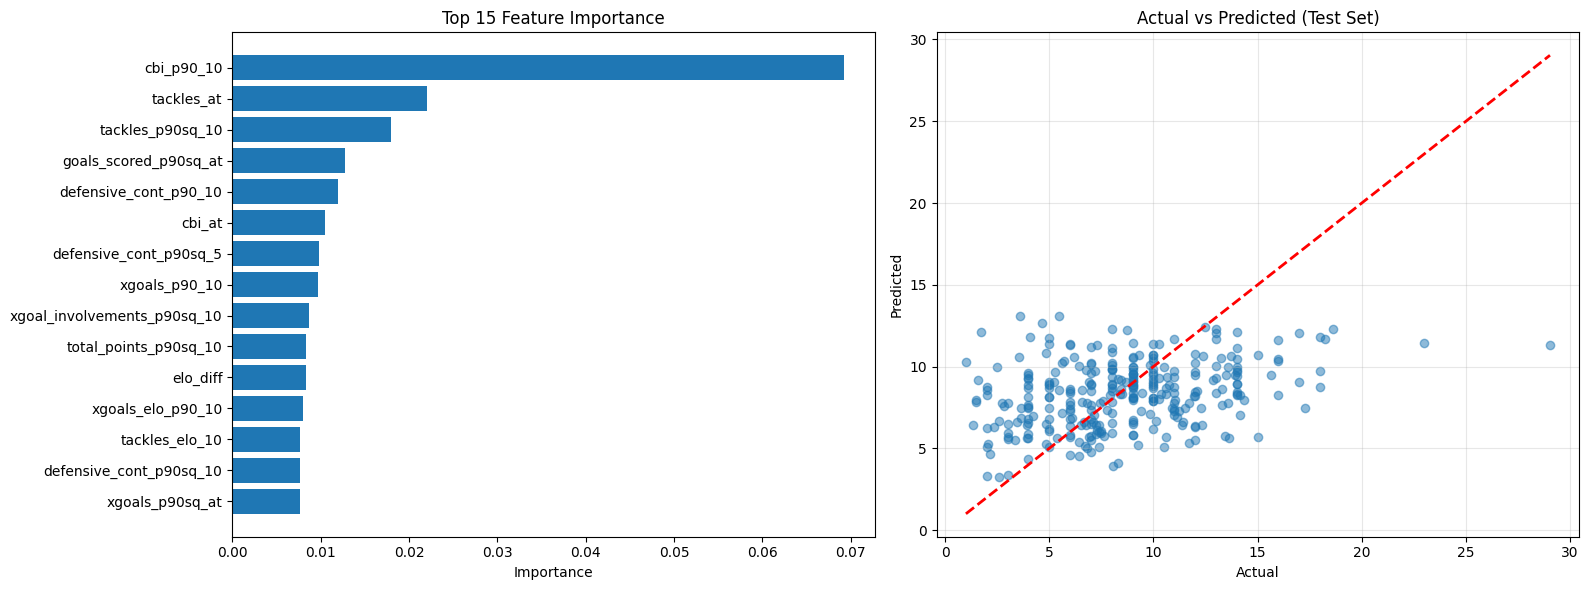

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1286/16746

Training Set Performance:
R² Score: 0.7652
RMSE: 1.8578
MAE: 1.4817

Test Set Performance:
R² Score: 0.0902
RMSE: 3.8731
MAE: 3.1108

Top 20 Feature Importances:
                                   feature  importance
                               cbi_p90sq_3    0.035155
xgoal_involvements_x_defensive_cont_p90_at    0.017740
                           opp_team_elo_10    0.016159
                                  elo_diff    0.014189
                                     cbi_5    0.013572
                              opp_team_elo    0.012032
                     opp_team_elo_p90sq_at    0.011891
                                    cbi_at    0.011745
                       xassists_elo_p90_10    0.010539
                                    cbi_10    0.010441
                                 cbi_p90_3    0.009851
                    opp_team_elo_elo_p90_5    0.009523
                            opp_team

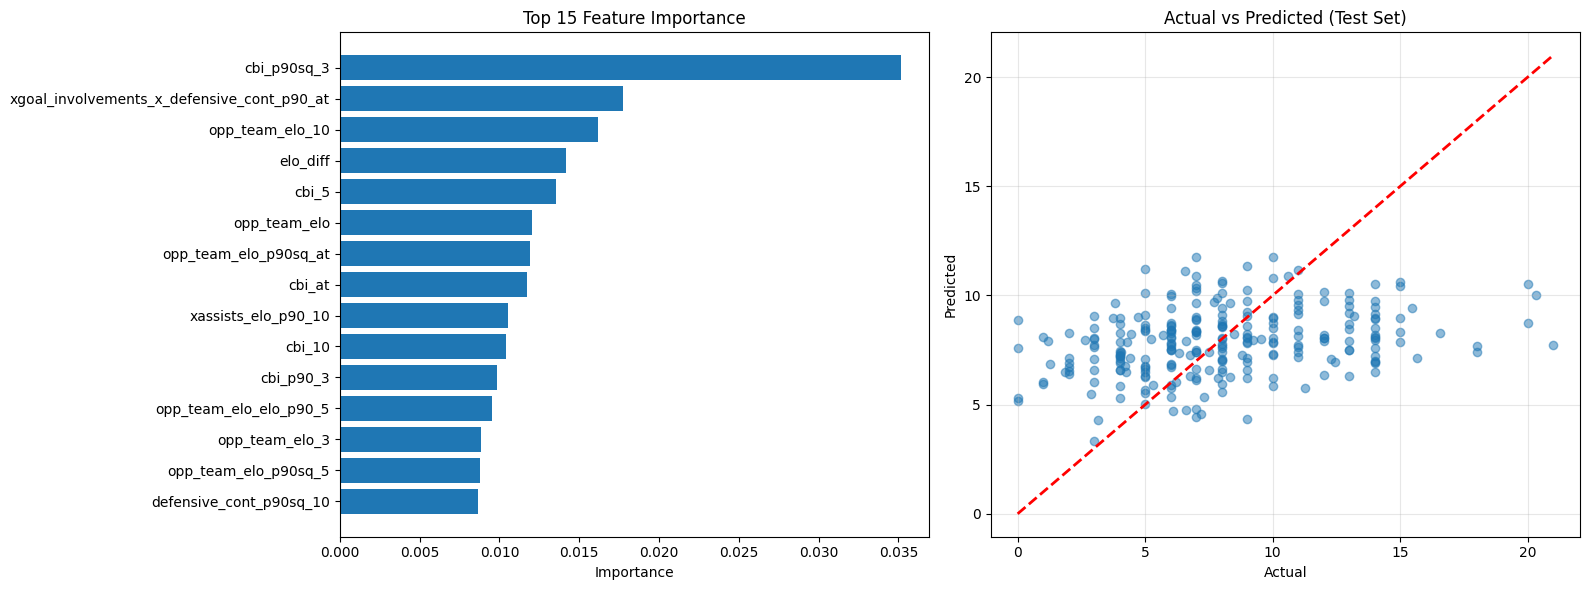

In [226]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'FWD'})
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'MID'})
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
    data=df[filtered],
    target='defensive_contribution_per90',
    positions={'DEF'})
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

Goals conceded per 90
Estimated λ (mean goals per match): 1.344


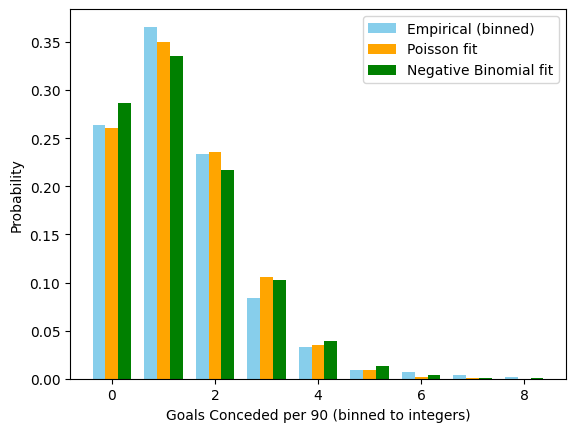

Mean: 1.336, Variance: 1.524
Overdispersion ratio (Var/Mean): 1.140
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.261


In [227]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
df['xgc_p90'] = (df['expected_goals_conceded'] / df['minutes']) * 90

# Filter to reasonable samples
data = df[(df['minutes'] > 0) & (df['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.311


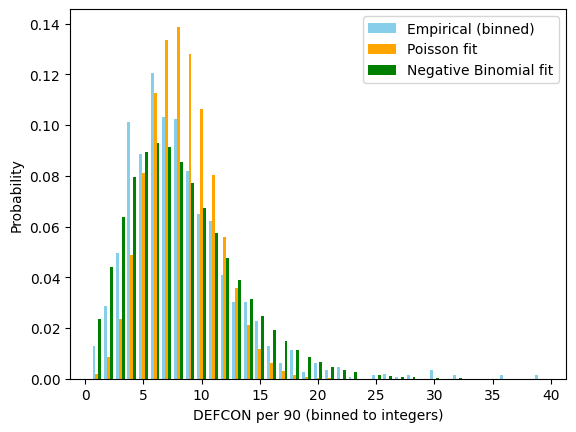

Mean: 8.303, Variance: 22.147
Overdispersion ratio (Var/Mean): 2.667
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [228]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean defcon per 90): 3.209


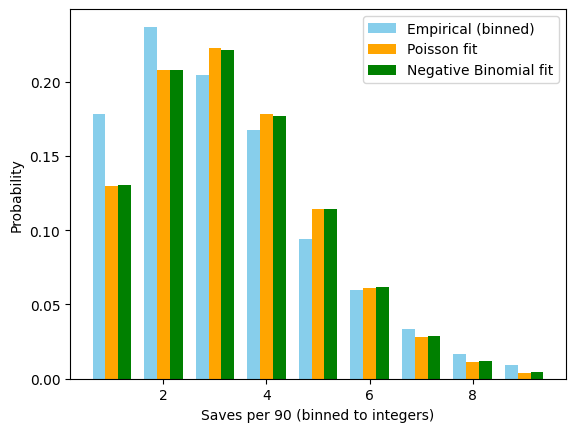

Mean: 3.209, Variance: 3.255
Overdispersion ratio (Var/Mean): 1.014
✅ Poisson assumption looks reasonable.


In [229]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.447
Model:                            OLS   Adj. R-squared (uncentered):              0.447
Method:                 Least Squares   F-statistic:                          3.272e+04
Date:                Mon, 15 Dec 2025   Prob (F-statistic):                        0.00
Time:                        12:36:46   Log-Likelihood:                         -38077.
No. Observations:               40415   AIC:                                  7.616e+04
Df Residuals:                   40414   BIC:                                  7.617e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

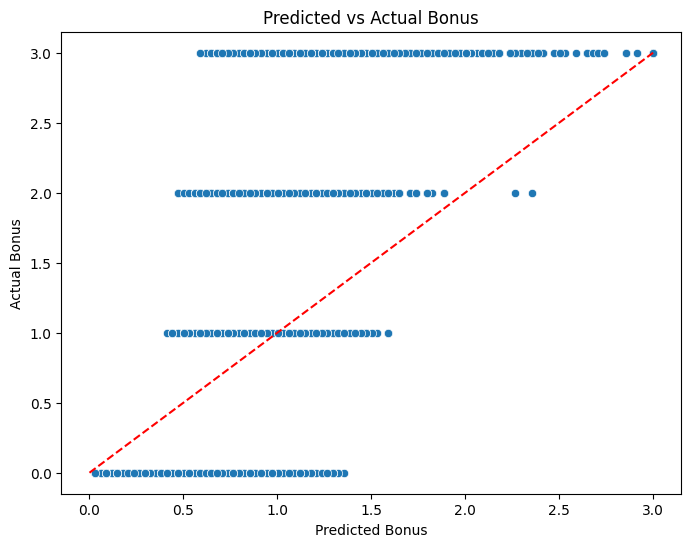

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459245  0.231413  1.106868  1.949018
FWD           0.331600  0.199676  1.047810  1.710418
GK            0.491634  0.246340  1.116651  2.014234
GKP                NaN       NaN       NaN       NaN
MID           0.394927  0.246230  1.051179  1.823960


In [230]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
filtered = (df['minutes']>45) & (df['bonus']>=0) & (df['bps']>0) & (df['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=df[filtered]).fit()
print(model.summary())

df['bonus_pred'] = model.predict(df[filtered])
df['bonus_pred'] = np.clip(df['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=df)
plt.plot([df['bonus'].min(), df['bonus'].max()],
         [df['bonus'].min(), df['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = df.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [231]:
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [232]:
prediction_data.pivot_table(index='event',values='minutes',aggfunc='count')

,minutes
event,
17.0,0
18.0,0
19.0,0
20.0,0
21.0,0
22.0,0
23.0,0
24.0,0
25.0,0


In [233]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [234]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    10230.000000
mean        41.563549
std         28.643496
min          0.865012
25%         15.619852
50%         38.816684
75%         68.741701
max         89.995275
Name: mins_pred, dtype: float64

In [235]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    9570.000000
mean        0.195353
std         0.162135
min         0.015386
25%         0.054564
50%         0.154889
75%         0.299070
max         0.745113
Name: xgp90_pred, dtype: float64

In [236]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    9570.000000
mean        0.110817
std         0.074237
min         0.015378
25%         0.048840
50%         0.094585
75%         0.158005
max         0.440731
Name: xap90_pred, dtype: float64

In [237]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    10230.000000
mean         1.359256
std          0.341729
min          0.466105
25%          1.110343
50%          1.291063
75%          1.571609
max          2.588914
Name: xgcp90_pred, dtype: float64

In [238]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    10230.000000
mean        17.417628
std          6.016530
min          1.262804
25%         13.911821
50%         16.796904
75%         20.806911
max         46.544191
Name: xbpsp90_pred, dtype: float64

In [239]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    660.000000
mean       2.795937
std        0.564413
min        1.249048
25%        2.464795
50%        2.795305
75%        3.151653
max        4.265197
Name: xsavesp90_pred, dtype: float64

In [240]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    9570.000000
mean        7.780745
std         2.097625
min         2.221360
25%         6.232247
50%         7.988735
75%         9.296898
max        12.798128
Name: xdefconp90_pred, dtype: float64

In [241]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
128998,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,17.0,Burnley,882.343528,1.303359,0.403768,0.250484,1.210448
129112,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,18.0,Brentford,1050.843741,1.285883,0.309292,0.144263,1.320979
129125,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,19.0,Chelsea,1145.288732,1.285883,0.312697,0.110538,1.568835
129148,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,20.0,Arsenal,1249.243891,1.285883,0.312577,0.111221,1.634488
129182,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,21.0,Spurs,1011.545501,1.285883,0.306304,0.144246,1.242833


In [242]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
134562,Erling Haaland,430.0,150.0,Man City,FWD,20252026.0,17.0,West Ham,983.838977,79.259454,0.738713,0.085155,1.183625
146473,Viktor Gyökeres,666.0,88.0,Arsenal,FWD,20252026.0,17.0,Everton,1072.697156,52.979423,0.674360,0.046439,1.050787
144568,Rodrigo Muniz Carvalho,338.0,54.0,Fulham,FWD,20252026.0,17.0,Nott'm Forest,1042.181380,0.865012,0.658591,0.160644,1.505462
130934,Armando Broja,680.0,52.0,Burnley,FWD,20252026.0,17.0,Bournemouth,1054.494175,51.926459,0.652547,0.068125,1.845882
130986,Ashley Barnes,218.0,43.0,Burnley,FWD,20252026.0,17.0,Bournemouth,1054.494175,1.089380,0.645418,0.141625,2.413884
132617,Christantus Uche,732.0,55.0,Crystal Palace,FWD,20252026.0,17.0,Leeds,948.486196,11.654348,0.642331,0.153618,1.279674
143097,Norberto Bercique Gomes Betuncal,311.0,50.0,Everton,FWD,20252026.0,17.0,Arsenal,1249.243891,18.601590,0.626481,0.130977,1.633631
132043,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,17.0,Man City,1244.963275,1.127330,0.624403,0.148897,2.538542
146728,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,17.0,Chelsea,1145.288732,6.543131,0.623865,0.170450,1.593195
139033,Kai Havertz,30.0,73.0,Arsenal,FWD,20252026.0,17.0,Everton,1072.697156,0.960966,0.623151,0.202350,1.559629


In [243]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [244]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [245]:
scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] >= 60:
            return 2
        elif x['mins_pred'] > 0:
            return 1
        else:
            return 0
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\282654768.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\chris\AppData\Local\Temp\ipykernel_11896\282654768.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\chris\AppData\Local\Temp\ipykernel_

In [246]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]
predictions

,player_name_id,team_name,team_elo,element,position,opp_team_name,opp_team_elo,season,value,event,...,xgcp90_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
127460,Bashir Humphreys,Burnley,882.343528,193.0,DEF,Nott'm Forest,1042.181380,20252026.0,39.0,33.0,...,1.982297,1,0.030558,0.017544,0.551010,0.0,-0.745853,0.556794,0.255450,1.665504
127944,Bashir Humphreys,Burnley,882.343528,193.0,DEF,Man City,1244.963275,20252026.0,39.0,34.0,...,1.963748,1,0.031256,0.019401,0.561326,0.0,-0.736761,0.556794,0.206044,1.638060
127951,Bashir Humphreys,Burnley,882.343528,193.0,DEF,Leeds,948.486196,20252026.0,39.0,35.0,...,2.516619,1,0.030186,0.016534,0.322928,0.0,-1.009599,0.556794,0.344137,1.260981
128171,Bashir Humphreys,Burnley,882.343528,193.0,DEF,Aston Villa,1180.983956,20252026.0,39.0,36.0,...,1.942594,1,0.030934,0.018884,0.573327,0.0,-0.726400,0.556794,0.206571,1.660109
128200,Bashir Humphreys,Burnley,882.343528,193.0,DEF,Arsenal,1249.243891,20252026.0,39.0,37.0,...,1.948642,1,0.031256,0.019401,0.569870,0.0,-0.729361,0.556794,0.202510,1.650470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147327,Álex Jiménez Sánchez,Bournemouth,1054.494175,713.0,DEF,Leeds,948.486196,20252026.0,45.0,34.0,...,1.011422,1,0.062547,0.021784,1.454805,0.0,-0.288781,0.556794,0.505964,3.313114
147328,Álex Jiménez Sánchez,Bournemouth,1054.494175,713.0,DEF,Crystal Palace,1107.584606,20252026.0,45.0,35.0,...,1.350549,1,0.060111,0.019376,1.036392,0.0,-0.442056,0.556794,0.306573,2.537189
147329,Álex Jiménez Sánchez,Bournemouth,1054.494175,713.0,DEF,Fulham,1036.365466,20252026.0,45.0,36.0,...,1.066898,1,0.062339,0.019814,1.376297,0.0,-0.313046,0.556794,0.326202,3.028401
147330,Álex Jiménez Sánchez,Bournemouth,1054.494175,713.0,DEF,Man City,1244.963275,20252026.0,45.0,37.0,...,1.833893,1,0.062227,0.019894,0.639161,0.0,-0.673310,0.556794,0.184576,1.789342


In [247]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>60)
    #&(prediction_data['position'].isin(['MID','FWD']))
    ][["player_name_id","element","value","team_name","position","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xdefconp90_pred','xbpsp90_pred','xpoints'
    ]].sort_values(by='xpoints',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xdefconp90_pred,xbpsp90_pred,xpoints
143906,Phil Foden,414.0,87.0,Man City,MID,17.0,West Ham,983.838977,72.887342,0.495016,0.205023,9.028843,38.111819,6.582787
142831,Nico O'Reilly,411.0,52.0,Man City,DEF,17.0,West Ham,983.838977,82.889465,0.160647,0.101320,7.335031,25.488948,6.175452
134562,Erling Haaland,430.0,150.0,Man City,FWD,17.0,West Ham,983.838977,79.259454,0.738713,0.085155,4.263934,23.767602,5.795333
132082,Bukayo Saka,16.0,102.0,Arsenal,MID,17.0,Everton,1072.697156,62.710979,0.326023,0.312580,8.337031,39.542898,5.718363
147202,Yéremy Pino Santos,712.0,58.0,Crystal Palace,MID,17.0,Leeds,948.486196,77.298319,0.306256,0.253772,7.311395,23.743961,5.512001
131874,Bruno Borges Fernandes,449.0,92.0,Man Utd,MID,17.0,Aston Villa,1180.983956,61.545287,0.451723,0.300959,10.384956,21.918668,5.439767
144238,Riccardo Calafiori,7.0,57.0,Arsenal,DEF,17.0,Everton,1072.697156,67.886393,0.074125,0.036430,6.689280,18.061695,5.269362
142626,Neco Williams,508.0,47.0,Nott'm Forest,DEF,17.0,Fulham,1036.365466,86.918664,0.081650,0.083186,6.966777,19.080898,5.268861
144874,Rúben dos Santos Gato Alves Dias,408.0,56.0,Man City,DEF,17.0,West Ham,983.838977,85.314431,0.087204,0.032635,9.010370,22.252381,5.253795
138701,Joško Gvardiol,403.0,59.0,Man City,DEF,17.0,West Ham,983.838977,70.995429,0.069191,0.082839,8.141954,21.774178,5.171171


In [248]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          10230 non-null  object 
 1   team_name               10230 non-null  object 
 2   team_elo                10230 non-null  float64
 3   element                 10230 non-null  float64
 4   position                10230 non-null  object 
 5   opp_team_name           10230 non-null  object 
 6   opp_team_elo            10230 non-null  float64
 7   season                  10230 non-null  float64
 8   value                   10230 non-null  float64
 9   event                   10230 non-null  float64
 10  mins_pred               10230 non-null  float64
 11  xgp90_pred              9570 non-null   float64
 12  xap90_pred              9570 non-null   float64
 13  xgcp90_pred             10230 non-null  float64
 14  xpoints_mins            10230 non-null

In [249]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [250]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [251]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 17 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
143906,Phil Foden,414.0,17.0,87.0,Man City,MID,West Ham,983.838977,72.887342,2,2.004468,0.498119,0.461553,0.0,0.000000,0.498159,1.120487,6.582787
142831,Nico O'Reilly,411.0,17.0,52.0,Man City,DEF,West Ham,983.838977,82.889465,2,0.887728,0.279946,1.883601,0.0,-0.181991,0.556794,0.749375,6.175452
134562,Erling Haaland,430.0,17.0,150.0,Man City,FWD,West Ham,983.838977,79.259454,2,2.602220,0.224978,0.000000,0.0,0.000000,0.269367,0.698768,5.795333
132082,Bukayo Saka,16.0,17.0,102.0,Arsenal,MID,Everton,1072.697156,62.710979,2,1.135846,0.653406,0.268390,0.0,0.000000,0.498159,1.162561,5.718363
147202,Yéremy Pino Santos,712.0,17.0,58.0,Crystal Palace,MID,Leeds,948.486196,77.298319,2,1.315169,0.653871,0.346729,0.0,0.000000,0.498159,0.698072,5.512001
131874,Bruno Borges Fernandes,449.0,17.0,92.0,Man Utd,MID,Aston Villa,1180.983956,61.545287,2,1.544524,0.617421,0.135254,0.0,0.000000,0.498159,0.644409,5.439767
144238,Riccardo Calafiori,7.0,17.0,57.0,Arsenal,DEF,Everton,1072.697156,67.886393,2,0.335471,0.082438,1.935203,0.0,-0.171557,0.556794,0.531014,5.269362
142626,Neco Williams,508.0,17.0,47.0,Nott'm Forest,DEF,Fulham,1036.365466,86.918664,2,0.473127,0.241013,1.667804,0.0,-0.230855,0.556794,0.560978,5.268861
144874,Rúben dos Santos Gato Alves Dias,408.0,17.0,56.0,Man City,DEF,West Ham,983.838977,85.314431,2,0.495986,0.092807,1.681476,0.0,-0.227489,0.556794,0.654220,5.253795
138701,Joško Gvardiol,403.0,17.0,59.0,Man City,DEF,West Ham,983.838977,70.995429,2,0.327485,0.196039,1.678829,0.0,-0.228137,0.556794,0.640161,5.171171


In [252]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW17 - GW21


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
371,Phil Foden,364.297253,10,10.062395,2.152889,1.768255,0.0,0.000000,2.490797,5.313573,31.787909
343,Nico O'Reilly,414.162880,10,4.419973,1.352530,8.074957,0.0,-1.236808,2.783970,3.661480,29.056102
121,Erling Haaland,400.990349,10,13.137097,0.819947,0.000000,0.0,0.000000,1.346834,3.465115,28.768994
58,Bukayo Saka,311.944895,10,5.623347,3.222311,1.395087,0.0,0.000000,2.490797,5.108793,27.840334
55,Bruno Borges Fernandes,290.603798,7,8.418292,3.329721,1.314904,0.0,0.000000,2.490797,4.994657,27.548371
97,Diego Gómez Amarilla,317.327067,10,8.680570,1.689977,1.377303,0.0,0.000000,2.490797,2.504368,26.743015
460,Yéremy Pino Santos,386.510787,10,6.297727,2.794118,1.509538,0.0,0.000000,2.490797,2.635289,25.727468
158,Harry Wilson,319.433431,10,6.171237,2.236452,1.321716,0.0,0.000000,2.490797,3.084335,25.304537
103,Dominik Szoboszlai,397.812210,10,5.298766,2.427636,1.712479,0.0,0.000000,2.490797,3.289893,25.219571
119,Enzo Fernández,383.695665,10,5.076153,3.396391,1.393430,0.0,0.000000,2.490797,2.724274,25.081044


In [253]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
371,Phil Foden,1601.706151,44,44.183625,9.865814,8.049469,0.0,0.000000,10.959507,22.721207,139.779621
343,Nico O'Reilly,1820.992362,44,21.615202,6.294795,36.189296,0.0,-5.293804,12.249469,15.903427,130.958385
121,Erling Haaland,1762.022152,44,57.780021,3.792173,0.000000,0.0,0.000000,5.926070,15.316512,126.814776
58,Bukayo Saka,1375.879267,44,25.051827,14.543494,7.340055,0.0,0.000000,10.959507,24.145532,126.040415
381,Riccardo Calafiori,1473.476339,44,8.135698,1.986880,41.895268,0.0,-4.027636,12.249469,11.897348,116.137027
97,Diego Gómez Amarilla,1396.103593,44,37.496054,6.458961,6.449425,0.0,0.000000,10.959507,10.690089,116.054036
55,Bruno Borges Fernandes,1305.904450,33,34.735435,13.800640,5.593302,0.0,0.000000,10.959507,16.843940,114.932823
158,Harry Wilson,1402.983746,44,27.893498,10.219059,6.500173,0.0,0.000000,10.959507,14.757128,114.329364
119,Enzo Fernández,1679.910447,44,23.723472,15.518492,6.190241,0.0,0.000000,10.959507,13.161181,113.552894
460,Yéremy Pino Santos,1694.273525,44,28.039002,12.042747,6.734433,0.0,0.000000,10.959507,10.916296,112.691985


In [254]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': picks_current_gameweek
})

In [255]:
# # Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [256]:
# Step 1: Insert new predictions that don't exist yet
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, 
    opp_team_elo, value, event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,  -- Add these explicitly
    fixture, total_points, minutes, goals_scored, assists, bonus, 
    bps, clean_sheets, goals_conceded, was_home, expected_assists, 
    expected_goal_involvements, expected_goals, expected_goals_conceded, 
    starts, cbi, defensive_contribution, recoveries, tackles, saves
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, 
    p.opp_team_name, p.opp_team_elo, p.value, p.event, p.season, 
    p.xpoints, p.prediction_timestamp, p.prediction_gameweek,  -- Include new columns
    pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, 
    pg.bonus, pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, 
    pg.expected_assists, pg.expected_goal_involvements, pg.expected_goals, 
    pg.expected_goals_conceded, pg.starts, pg.cbi, pg.defensive_contribution, 
    pg.recoveries, pg.tackles, pg.saves
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season
WHERE NOT EXISTS (
    SELECT 1 
    FROM predictions_allgws pa 
    WHERE pa.player_name_id = p.player_name_id 
        AND pa.event = p.event 
        AND pa.season = p.season
);
""")

In [257]:
# # Step 1: Insert new predictions that don't exist yet
# db_creator.execute_sql("""
# INSERT INTO predictions_allgws
# SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
# FROM predictions p
# LEFT JOIN playergw pg 
#     ON p.player_name_id = pg.player_name_id 
#     AND p.event = pg.event 
#     AND p.season = pg.season
# WHERE NOT EXISTS (
#     SELECT 1 
#     FROM predictions_allgws pa 
#     WHERE pa.player_name_id = p.player_name_id 
#         AND pa.event = p.event 
#         AND pa.season = p.season
# );
# """)

# # Step 2: Update existing predictions with actual results (where total_points is still NULL)
# db_creator.execute_sql("""
# UPDATE predictions_allgws
# SET 
#     fixture = pg.fixture,
#     total_points = pg.total_points,
#     minutes = pg.minutes,
#     goals_scored = pg.goals_scored,
#     assists = pg.assists,
#     bonus = pg.bonus,
#     bps = pg.bps,
#     clean_sheets = pg.clean_sheets,
#     goals_conceded = pg.goals_conceded,
#     expected_assists = pg.expected_assists,
#     expected_goal_involvements = pg.expected_goal_involvements,
#     expected_goals = pg.expected_goals,
#     expected_goals_conceded = pg.expected_goals_conceded,
#     starts = pg.starts,
#     cbi = pg.cbi,
#     defensive_contribution = pg.defensive_contribution,
#     recoveries = pg.recoveries,
#     tackles = pg.tackles,
#     saves = pg.saves
# FROM playergw pg
# WHERE predictions_allgws.player_name_id = pg.player_name_id
#     AND predictions_allgws.event = pg.event
#     AND predictions_allgws.season = pg.season
#     AND predictions_allgws.total_points IS NULL;  -- Only update rows without actual points yet
# """)

# print(f"Successfully added/updated gameweek {picks_current_gameweek} predictions in predictions_allgws")

In [258]:
# # # Create predictions_allgws if it doesn't exist, otherwise append
# # # creates new rows every time the script is loaded
# # db_creator.execute_sql("""
# #     CREATE TABLE IF NOT EXISTS predictions_allgws AS
# #     SELECT * FROM predictions WHERE 1=0;  -- Creates empty table with same schema, 1=0 ensures no data copied, just structure
    
# #     INSERT INTO predictions_allgws
# #     SELECT * FROM predictions;
# # """)

# # Create predictions_allgws if it doesn't exist
# db_creator.execute_sql("""
#     CREATE TABLE IF NOT EXISTS predictions_allgws AS
#     SELECT p.*,
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves 
            
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season
#     WHERE 1=0;  -- Empty table with correct schema
# """)

# # Insert new predictions from current gameweek
# db_creator.execute_sql("""
#     INSERT INTO predictions_allgws
#     SELECT p.*, 
#             -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value,
#             pg.fixture, pg.total_points, pg.minutes, pg.goals_scored, pg.assists, pg.bonus, 
#             pg.bps, pg.clean_sheets, pg.goals_conceded, pg.was_home, pg.expected_assists, 
#             pg.expected_goal_involvements, pg.expected_goals, pg.expected_goals_conceded, 
#             pg.starts, pg.cbi, pg.defensive_contribution, pg.recoveries, pg.tackles, pg.saves
                       
#     FROM predictions p
#     LEFT JOIN playergw pg 
#         ON p.player_name_id = pg.player_name_id 
#         AND p.event = pg.event
#         AND p.season = pg.season;
# """)

# print(f"Successfully added gameweek {picks_current_gameweek} predictions to predictions_allgws")

In [259]:
df = db_creator.table_to_df('predictions_allgws')
future_filter = (#df['season']==20252026)&(
                #df['event']>=13)&(
                df['prediction_gameweek']==16)
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes


In [260]:
df = db_creator.table_to_df('playergw')
future_filter = (df['season']==20252026)&(df['event']>=13)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','total_points','minutes']][future_filter].head()

,player_name_id,event,season,total_points,minutes
178219,Erling Haaland,13.0,20252026.0,2.0,90.0
178220,Erling Haaland,14.0,20252026.0,14.0,90.0
178221,Erling Haaland,15.0,20252026.0,2.0,68.0
178222,Erling Haaland,16.0,20252026.0,13.0,90.0
191102,Erling Haaland,17.0,20252026.0,NaN,NaN


In [261]:
df = db_creator.table_to_df('predictions')
future_filter = (df['season']==20252026)&(df['event']<=20)&(df['player_name_id']=='Erling Haaland')
df[['player_name_id','event','season','xpoints']][future_filter]

,player_name_id,event,season,xpoints
8744,Erling Haaland,17.0,20252026.0,5.795333
8745,Erling Haaland,18.0,20252026.0,5.767746
8746,Erling Haaland,19.0,20252026.0,5.747478
8747,Erling Haaland,20.0,20252026.0,5.717161


In [262]:
df = db_creator.table_to_df('predictions_allgws')
df[['player_name_id','prediction_timestamp','event','xpoints','total_points','minutes']][
    (df['season']==20252026)&(
    df['event']<=17)&(df['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points,minutes
42036,Erling Haaland,2025-12-02 12:42:34.616921,14.0,5.792425,14.0,90.0
42037,Erling Haaland,2025-12-02 12:21:57.509787,14.0,5.792425,14.0,90.0
42000,Erling Haaland,2025-12-02 12:42:34.616921,15.0,5.546765,2.0,68.0
42001,Erling Haaland,2025-12-03 13:22:30.909046,15.0,5.723294,2.0,68.0
42002,Erling Haaland,2025-12-02 12:21:57.509787,15.0,5.546765,2.0,68.0
42003,Erling Haaland,2025-12-03 13:22:30.909046,15.0,5.723294,2.0,68.0
11006,Erling Haaland,2025-12-02 12:21:57.509787,16.0,5.380279,10.0,90.0
11007,Erling Haaland,2025-12-03 13:22:30.909046,16.0,5.517031,10.0,90.0
11008,Erling Haaland,2025-12-02 12:42:34.616921,16.0,5.380279,10.0,90.0
11009,Erling Haaland,2025-12-03 13:22:30.909046,16.0,5.517031,10.0,90.0


In [263]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['prediction_gameweek']>=13)&(
            df['event']>=13)&(
                df['event']<=20)&(
            df['season']==20252026)&(
            df['player_name_id']=='Erling Haaland')
df_complete = df[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

total_points  \
prediction_timestamp       prediction_gameweek season     event                 
2025-12-02 12:21:57.509787 13                  20252026.0 14.0           14.0   
                                                          15.0            2.0   
                                                          16.0           10.0   
                                                          17.0            NaN   
                                                          18.0            NaN   
                                                          19.0            NaN   
                                                          20.0            NaN   
2025-12-02 12:42:34.616921 13                  20252026.0 14.0           14.0   
                                                          15.0            2.0   
                                                          16.0           10.0   
                                                          17.0            NaN   
                                                          18.0            NaN   
                                                          19.0            NaN   
                                                          20.0            NaN   
2025-12-03 13:22:30.909046 14                  20252026.0 15.0            2.0   
                                                          16.0           10.0   
                                                          17.0            NaN   
                                                          18.0            NaN   
                                                          19.0            NaN   
                                                          20.0            NaN   

                                                                  xpoints  
prediction_timestamp       prediction_gameweek season     event            
2025-12-02 12:21:57.509787 13                  20252026.0 14.0   5.792425  
                                                          15.0   5.546765  
                                                          16.0   5.380279  
                                                          17.0   5.757174  
                                                          18.0   5.727987  
                                                          19.0   5.546765  
                                                          20.0   4.732503  
2025-12-02 12:42:34.616921 13                  20252026.0 14.0   5.792425  
                                                          15.0   5.546765  
                                                          16.0   5.380279  
                                                          17.0   5.757174  
                                                          18.0   5.727987  
                                                          19.0   5.546765  
                                                          20.0   4.732503  
2025-12-03 13:22:30.909046 14                  20252026.0 15.0   5.723294  
                                                          16.0   5.517031  
                                                          17.0   5.790754  
                                                          18.0   5.716587  
                                                          19.0   5.723294  
                                                          20.0   4.524183

In [264]:
# Get the data from the predictions table
df = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df['event'] >= 13) & (df['minutes'] >= 1)
df_complete = df.dropna(subset=['total_points'])[gw_filter]

df_complete.pivot_table(index=['season','event'], values=['xpoints','total_points'], aggfunc='mean')

C:\Users\chris\AppData\Local\Temp\ipykernel_11896\686688159.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_complete = df.dropna(subset=['total_points'])[gw_filter]


total_points   xpoints
season     event                        
20252026.0 14.0       3.233333  3.302508
           15.0       3.078546  3.180474
           16.0       3.031549  3.160426

Correlation: 0.273
Mean Absolute Error: 2.269
Root Mean Squared Error: 3.038


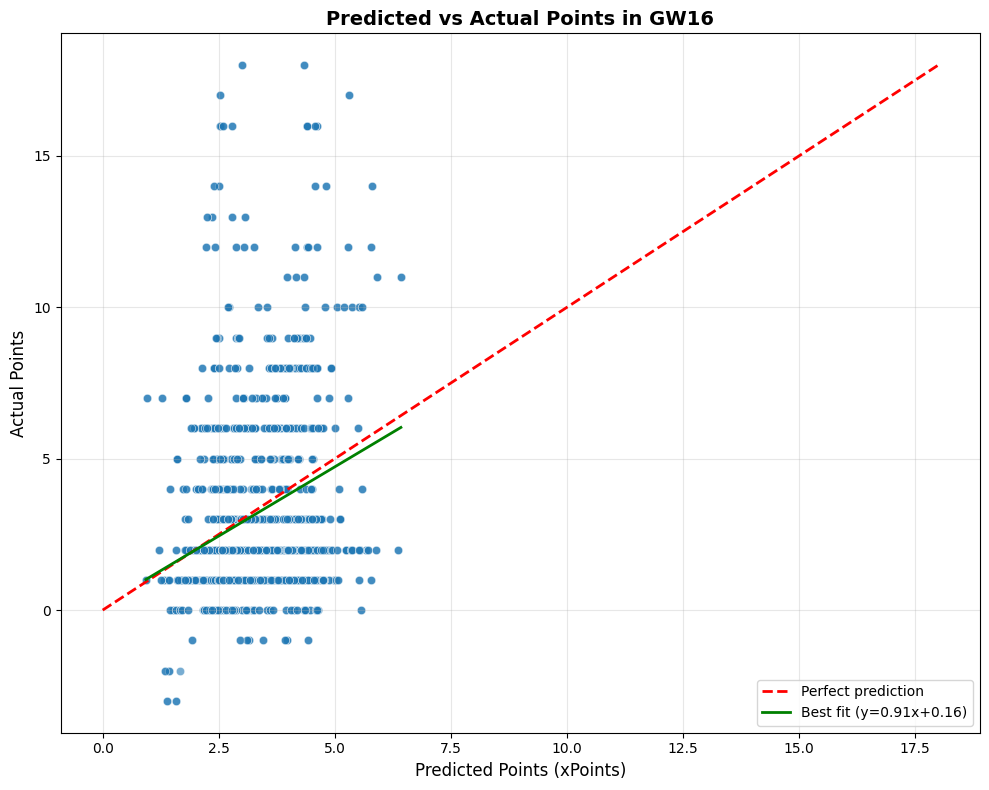

In [265]:
# Create the plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# Add a diagonal reference line (perfect predictions)
max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# Add regression line showing actual correlation
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

plt.xlabel('Predicted Points (xPoints)', fontsize=12)
plt.ylabel('Actual Points', fontsize=12)
plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [266]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 17.5 minute(s)
